<style>
    /* we can use injections to style the resulting pdf */

    /* wrapping */
    pre, .jp-CodeCell .jp-Editor {
        display: block!important;
    }
    .jp-Cell-inputArea pre {
           page-break-inside: avoid !important;
    }
    .cm-editor.cm-s-jupyter .highlight pre {
        white-space: pre-wrap !important;
    }

    /* margins */
    div#notebook-container,
    div.container,
    div#notebook,
    .jp-Notebook {
        max-width: none !important;
        width: 102.6% !important;
        margin-left: -2.6% !important;
        padding: 0 !important;
    }
    .jp-MarkdownCell {
        margin-left: -6px;
        margin-bottom: 8px;
        margin-top: 12px;
    }
    .jp-OutputArea .jp-RenderedText {
        padding-left: calc(1ch + 16px);
        padding-top: 4px;
        padding-bottom: 8px;
    }
</style>

# Homework #4. Exploratory Data Analysis

This document represents the first part of exploratory data analysis - some sanity checks and high-level overviews.

In the previous stage of work (downloading and understanding the dataset), as part of initial preparation, the downloaded data underwent basic cleaning and preparation, which included checking the expected structure of the dataset, filtering the necessary columns, deduplication, ensuring categorical consistency, and initial normalization (full information is provided in data_preparation.ipynb).

Within the scope of this detailed quality analysis, some previously made decisions were revised. This includes:

##### Expansion of the essential columns set:
For comments, the following columns have been added:
1. `controversiality` (integer, 0 or 1), which can be particularly useful for identifying contentious topics, ethical debates, and norm violations
2. `distinguished` (string, e.g., 'moderator'), which is useful for finding official announcements, rule clarifications, and norm enforcement.

For submissions, the following columns have been added:
1. `link_flair_text` (string), a human-labeled category can be used as powerful categorical variables
2. `upvote_ratio` (float), to measure contention at the submission level
3. `domain` (string) to be able to find out the domain for submissions that are links, which can help with mapping the subculture's ecosystem
distinguished
4. `distinguished` (string, e.g., 'moderator') - same as for comments

##### Revision of zero values handling:
The previous approach combined `[removed]`, `[deleted]`, and `''`, which are conceptually different markers, into a single category np.nan. We can assume that these elements convey different signals:

* `''` provides structural information about the type of post (if this is not an error, then no text was ever intended to be here)
* `[removed]` shows community governance signal (the post had text, but a mod deleted it, active moderation is happening)
* `[deleted] `shows user behavior signal (the post had text, but the user deleted it, self-censorship or regret)

Thus, it was decided to remove this stage from the preparation phase and work through it in detail here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import tqdm
import random
from joblib import Parallel, delayed
from sklearn.metrics import precision_recall_curve
import matplotlib.ticker as mtick

In [2]:
comments_df = pd.read_parquet('all_comments_cleaned_NEW2.parquet')
submissions_df = pd.read_parquet('all_submissions_cleaned_NEW2.parquet')

In [3]:
comments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3955713 entries, 0 to 3955712
Data columns (total 10 columns):
 #   Column            Dtype         
---  ------            -----         
 0   id                object        
 1   link_id           object        
 2   parent_id         object        
 3   created_utc       datetime64[ns]
 4   author            object        
 5   subreddit         object        
 6   body              object        
 7   score             int64         
 8   controversiality  int64         
 9   distinguished     object        
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 301.8+ MB


In [4]:
print(f"Date range: {comments_df['created_utc'].min()} to {comments_df['created_utc'].max()}")

Date range: 2023-05-01 00:00:04 to 2025-04-30 23:59:49


In [5]:
print(comments_df.sample(3))

              id  link_id parent_id         created_utc            author  \
640574   jw2kyo4  15pozmk   15pozmk 2023-08-13 23:46:07  Mammoth_Love_597   
1517806  jnhxitt  1440u8d   jneojly 2023-06-09 06:16:35         odder_sea   
1958251  jt2sioy  156uxna   156uxna 2023-07-23 03:05:46     disabled_crab   

                     subreddit  \
640574             CharacterAI   
1517806  ArtificialInteligence   
1958251             FanFiction   

                                                      body  score  \
640574   Me trying to remind the bot of my gender for t...      1   
1517806  Not just governments, we have all been active ...      1   
1958251  I never write civilian protagonists because I'...      1   

         controversiality distinguished  
640574                  0          None  
1517806                 0          None  
1958251                 0          None  


In [6]:
submissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392439 entries, 0 to 392438
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id               392439 non-null  object        
 1   created_utc      392439 non-null  datetime64[ns]
 2   author           392439 non-null  object        
 3   subreddit        392439 non-null  object        
 4   title            392439 non-null  object        
 5   selftext         392439 non-null  object        
 6   score            392439 non-null  int64         
 7   upvote_ratio     392439 non-null  float64       
 8   link_flair_text  392439 non-null  object        
 9   domain           392439 non-null  object        
 10  distinguished    392439 non-null  object        
 11  num_comments     392439 non-null  int64         
 12  over_18          392439 non-null  object        
 13  url              392439 non-null  object        
 14  permalink        392

In [7]:
print(submissions_df.sample(3))

             id         created_utc                author   subreddit  \
59174   153xooq 2023-07-19 15:09:44         2muchnet42day  LocalLLaMA   
345641  1c79dup 2024-04-18 17:38:18   Flashy-Drummer-4198     ChatGPT   
88772   15nxif5 2023-08-11 03:31:22  Majestic_Kangaroo319  LocalLLaMA   

                                                    title  \
59174   Locally hosted documentation with LLM support ...   
345641                                     HELP!!!!!!!!!!   
88772   Building a hosted transcription index using Ll...   

                                                 selftext  score  \
59174   Does anyone know what options there may be for...      1   
345641                                          [removed]      1   
88772   Can anyone recommend a code repo  to build and...      1   

        upvote_ratio                   link_flair_text           domain  \
59174            1.0                   Question | Help  self.LocalLLaMA   
345641           1.0  Serious replies o

#### 1.1. Null handling

In [8]:
print("Comments Nulls:")
print(comments_df.isnull().sum())

Comments Nulls:
id                  0
link_id             0
parent_id           0
created_utc         0
author              0
subreddit           0
body                0
score               0
controversiality    0
distinguished       0
dtype: int64


In [9]:
print("Submissions Nulls:")
print(submissions_df.isnull().sum())

Submissions Nulls:
id                 0
created_utc        0
author             0
subreddit          0
title              0
selftext           0
score              0
upvote_ratio       0
link_flair_text    0
domain             0
distinguished      0
num_comments       0
over_18            0
url                0
permalink          0
dtype: int64


A basic check shows that there are no null values. This is to be expected, given the above-described rejection of null processing during the basic preparation stage. It also allows us to verify that other columns do not contain unexpected null values.

But, as stated before, differentiating between `[removed]` (moderator) and `[deleted]` (user) is crucial. For a more detailed review, we'll perform an analysis of common placeholders. Hypothesis here: `[removed]` and `[deleted]` are the primary placeholders, but other automated or templated text might exist.

In [10]:
# we filter for comments with some substance to avoid single-word answers ("yes", "no")
# but not so long that they are unlikely to be templates

print("Top 20 most frequent, non-trivial comment bodies:")
comment_bodies = comments_df['body']
frequent_comments = comment_bodies[comment_bodies.str.len().between(5, 150)].value_counts().head(20)
print(frequent_comments)

Top 20 most frequent, non-trivial comment bodies:
body
[removed]                   171987
[deleted]                    46355
Thank you!                    2202
Thanks!                       1321
Thank you                     1113
Thanks                        1030
Good bot                       692
What?                          556
Based                          483
Same here                      419
Exactly                        417
Happy birthday                 396
Me too                         384
Thank you.                     370
Agreed                         344
Same.                          343
Dm me                          328
I also left a review! :D       302
Interesting                    296
Thank you so much!             292
Name: count, dtype: int64


In [11]:
print("Top 20 most frequent, non-trivial submission titles:")
submission_texts = submissions_df['title']
frequent_submissions = submission_texts[submission_texts.str.len().between(5, 150)].value_counts().head(20)
print(frequent_submissions)

Top 20 most frequent, non-trivial submission titles:
title
[image processing failed]               332
Site down                               155
What?                                   141
Question                                137
Lonely                                  136
Title                                   103
Anyone up for chat? Indian male here    100
Excuse me?                               90
Hello                                    83
Here we go again                         82
Site down?                               79
NOT AGAIN                                78
I need help                              72
What.                                    69
[ Removed by Reddit ]                    69
Help?                                    65
Anyone else?                             64
NOOOO                                    63
Anyone wanna chat and be friends?        62
No context                               56
Name: count, dtype: int64


In [12]:
print("Top 20 most frequent, non-trivial submission selftexts:")
submission_texts = submissions_df['selftext']
frequent_submissions = submission_texts[submission_texts.str.len().between(5, 150)].value_counts().head(20)
print(frequent_submissions)

Top 20 most frequent, non-trivial submission selftexts:
selftext
[removed]                                                                                                                                         57102
[deleted]                                                                                                                                         14067
Title                                                                                                                                                69
Indian male here                                                                                                                                     62
title                                                                                                                                                42
Here on Writing Weekends, share what you are going to write and are currently writing this weekend or if you're gonna take the weekend off.          30
Share the last review y

In [13]:
# an example of such short comments that can be marked in the future
print("Low-content comments")
print(f"Comments with 1-3 characters: {len(comment_bodies[comments_df['body'].str.len().between(1, 3)])}\n")
print(f"Example of short comments:\n{comments_df[comments_df['body'].str.len().between(1, 3)]['body'].value_counts().head(20)}")

Low-content comments
Comments with 1-3 characters: 46261

Example of short comments:
body
Yes    2555
No     1754
Lol    1422
lol     826
💀       821
😂       724
No.     722
👍       719
Hi      676
yes     649
Ok      585
Yep     558
no      522
?       498
Fr      484
🫂       437
🤣       416
LOL     407
Wow     405
😭       383
Name: count, dtype: int64


Besides the expected results, we see a recurring pattern of posts, probably from r/lonely (Indian man here...). Let's check it out right away.

In [14]:
# use .str.contains() to catch all variations of this pattern
lonely_pattern_df = submissions_df[submissions_df['selftext'].str.contains("Indian male here", na=False)]
print(f"Found {len(lonely_pattern_df)} posts containing this pattern. Subreddit distribution for these posts:")
print(lonely_pattern_df['subreddit'].value_counts())

Found 112 posts containing this pattern. Subreddit distribution for these posts:
subreddit
lonely    112
Name: count, dtype: int64


This is probably a form of subcultural norm within that specific community. Although it is not relevant to our analysis, it may be useful in later stages, such as keyword filtering to eliminate noise.

More critically, we see the format `“Removed by Reddit on account of violating...”`. Unlike other types of deleted content markers, this one is of particular interest - it is an admin action, that is performed after a violation of site-wide content policy. This is reserved for serious offenses like illegal content, targeted harassment, copyright infringement, etc. Let's investigate this in more detail:

In [15]:
admin_removed_text = "[ Removed by Reddit on account of violating the [content policy](/help/contentpolicy). ]"
admin_removed_df = submissions_df[submissions_df['selftext'] == admin_removed_text]

print(f"Found {len(admin_removed_df)} posts that were removed by reddit admins\n")

print('Subreddit distribution for these posts:')
print(admin_removed_df['subreddit'].value_counts())

print('\nDataset example:')
print(admin_removed_df[['subreddit', 'title', 'score', 'link_flair_text', 'num_comments']])

Found 10 posts that were removed by reddit admins

Subreddit distribution for these posts:
subreddit
lonely        6
ChatGPT       3
FanFiction    1
Name: count, dtype: int64

Dataset example:
         subreddit                                              title  score  \
215978      lonely                              [ Removed by Reddit ]      0   
235835  FanFiction                              [ Removed by Reddit ]      0   
247439      lonely                    My best friend doesn't love me.      2   
248901      lonely  [16/F] here not really sure what I'm doing her...      0   
259830     ChatGPT  The best ChatGPT tools without API Key [ChatGP...      3   
274413      lonely                                     please kill me      1   
283593     ChatGPT                            AI Undetectable Writing      1   
322559      lonely  Thinking about hiring a male escort (I’m a woman)      1   
322845      lonely  the next time someone cancels or flakes on me ...      1   
339392 

We see another similar format - `[Removed by Reddit]` for tittle. Let's analyze it as well.

In [16]:
admin_removed_text = "[ Removed by Reddit ]"
admin_removed_df2 = submissions_df[submissions_df['title'] == admin_removed_text]

print(f"Found {len(admin_removed_df2)} posts that were removed by reddit admins.\n")

print('Subreddit distribution for these posts:')
print(admin_removed_df2['subreddit'].value_counts())

print('\nDataset example:')
print(admin_removed_df2[['subreddit', 'selftext', 'score', 'link_flair_text', 'num_comments']] \
    .sort_values(by='score', ascending=False) \
    .head(10))

Found 69 posts that were removed by reddit admins.

Subreddit distribution for these posts:
subreddit
lonely         22
CharacterAI    21
ChatGPT        18
singularity     5
FanFiction      2
LocalLLaMA      1
Name: count, dtype: int64

Dataset example:
          subreddit                                           selftext  score  \
16047    LocalLLaMA                                          [removed]    166   
7106    CharacterAI                                          [removed]     28   
240105       lonely                                          [removed]      4   
20322   CharacterAI                                          [removed]      3   
208734       lonely                                          [removed]      2   
261543       lonely  I wanna die. I’m ugly and gross and I’m too ol...      1   
282147       lonely  Im sick of women shit. All because you have a ...      1   
11071   CharacterAI                                          [removed]      1   
13449   Character

The analysis was performed on the above datasets in full; for the report, they are presented in a shortened format.

A significant portion of admin-removed posts originates from r/lonely. The titles and the flairs point to users in extreme emotional distress -
reddit admins are likely intervening here not just for policy violations, but also as part of their "Reddit Cares" protocol. In a sense, this may provide a context for why people seek AI companionship, as a response to profound isolation and despair. This validates the inclusion of r/lonely as a crucial source of user motivation.

The r/ChatGPT and r/singularity show a different pattern - the flairs (Jailbreak, Gone Wild, Educational Purpose Only) and titles (AI Undetectable Writing) suggest users are pushing (intentionally or unintentionally) the boundaries of what is permissible with AI. This is important information in the context of our analysis of “unintended uses,” which will be explored in more detail in the following sections of the analysis.

The r/CharacterAI and r/LocalLLaMA do not fall under such broad categories. In the case of r/CharacterAI, as a platform with its own safety filters, admin removals could be related to users sharing methods to exploit the platform in ways that violate Reddit's TOS. Considering flair (🔥SITE DOWN🔥), perhaps a user posted something malicious or illegal during a chaotic period.

r/LocalLLaMA presents the most sudden and most popular result among similar posts (166 upvotes and 51 comments). Given the lack of other information and the uninformative link_flair_text, we can weakly assume that this could be a discussion about a dataset or model that contained illegal material or was trained on copyrighted data in a way that prompted a DMCA takedown.

In addition to providing information for further analysis, this stage allowed us to identify the full hierarchy of removal states. Based on this, we can derive a new ‘text_status’ categorical column.

In [17]:
def add_text_status_column(df, text_col='body'):
    # choices for categorization
    conditions = [
        df[text_col] == '[removed]',
        df[text_col] == '[deleted]',
        df[text_col].str.contains('Removed by Reddit', na=False), # catches both variants
        df[text_col].isin(['', None]),
        df[text_col].notna() # any other non-null value
    ]

    choices = [
        'removed_by_moderator',
        'deleted_by_user',
        'removed_by_admin',
        'empty', # post was intentionally blank (e.g., a link post with no selftext)
        'available' # the text is present and valid
    ]

    df['text_status'] = np.select(conditions, choices, default='unknown')

    return df

In [18]:
comments_df = add_text_status_column(comments_df, text_col='body')
submissions_df = add_text_status_column(submissions_df, text_col='selftext')

In [19]:
# a summary of how text content is distributed across these categories
print("Comment text status distribution:")
print(comments_df['text_status'].value_counts(normalize=True))

Comment text status distribution:
text_status
available               0.944782
removed_by_moderator    0.043478
deleted_by_user         0.011718
removed_by_admin        0.000020
empty                   0.000002
Name: proportion, dtype: float64


In [20]:
print("Submission text status distribution:")
print(submissions_df['text_status'].value_counts(normalize=True))

Submission text status distribution:
text_status
available               0.474255
empty                   0.344369
removed_by_moderator    0.145505
deleted_by_user         0.035845
removed_by_admin        0.000025
Name: proportion, dtype: float64



Distribution results for comment text are expected. In later stages, it will be useful to look at the difference in these statistics in terms of subreddits. In the case of submissions, we can observe an unexpectedly ‘empty’ large category.
It is likely that empty selftext corresponds to link/media posts, which can be confirmed using the domain column.

We can filter the submissions dataframe to only include posts where text_status == 'empty' and then examine the top domains for each subreddit.

In [21]:
empty_submissions = submissions_df[submissions_df['text_status'] == 'empty'].copy()
subreddits = empty_submissions['subreddit'].unique()

print(f"Total number of empty submissions: {len(empty_submissions)}")

Total number of empty submissions: 135144


In [22]:
for sub in sorted(subreddits):
    print(f"\nTop {10} domains for r/{sub}")

    sub_df = empty_submissions[empty_submissions['subreddit'] == sub]
    domain_counts = sub_df['domain'].value_counts()
    print(domain_counts.head(10))


Top 10 domains for r/ArtificialInteligence
domain
i.redd.it              118
reddit.com             114
youtube.com             68
self.ChatGPT            58
self.enoumen            37
youtu.be                35
techstormai.com         35
self.singularity        34
self.datascience        30
self.Jhonjournalist     30
Name: count, dtype: int64

Top 10 domains for r/CharacterAI
domain
i.redd.it            61655
reddit.com            9521
self.CharacterAI      7804
c.ai                   435
v.redd.it              205
beta.character.ai      204
youtube.com            143
youtu.be               131
i.imgur.com             77
tiktok.com              20
Name: count, dtype: int64

Top 10 domains for r/ChatGPT
domain
i.redd.it              17614
reddit.com              6658
self.ChatGPT            2050
v.redd.it               1491
youtu.be                 888
youtube.com              827
                         271
chat.openai.com          268
elblogdefamosas.com      231
i.imgur.com       

We can identify certain patterns in our tiers:

Tier 1 communities like r/LocalLLaMA act as technical knowledge hubs linking to GitHub, Hugging Face, and arXiv, while r/SillyTavernAI and r/JanitorAI_Official focus on practical use with little external linking. r/CharacterAI users heavily screenshot their platform interactions.Tier 2 and 3 shift from content curation (r/ChatGPT, r/singularity) and aggregation (r/ArtificialIntelligence) to text-based sharing (r/fanfiction). r/lonely does not have similar posts (a feature of the subreddit)

The information is within expectations. Important findings for the data quality check stage here are empty domain entries (“”) and spam domains (elblogdefamosas.com, hotelwarehouse.com).

In [23]:
# investigating the spam domains
spam_domains = ['hotelwarehouse.com', 'elblogdefamosas.com']
spam_posts = empty_submissions[empty_submissions['domain'].isin(spam_domains)]

In [24]:
print(f"Found {len(spam_posts)} posts linking to suspected spam domains. Authors posting these links:")
print(spam_posts['author'].value_counts())

print("\nSubreddits where these links are posted:")
print(spam_posts['subreddit'].value_counts())

Found 473 posts linking to suspected spam domains. Authors posting these links:
author
SuddenMath7596    242
trandanhreddit    231
Name: count, dtype: int64

Subreddits where these links are posted:
subreddit
singularity    242
ChatGPT        231
Name: count, dtype: int64


In [25]:
top_spammer = spam_posts['author'].value_counts().index[0]
print(f"\nExample titles from top spammer '{top_spammer}':")
print(spam_posts[spam_posts['author'] == top_spammer]['title'].head())


Example titles from top spammer 'SuddenMath7596':
241422    About This Item 9oz PP individually wrapped Pl...
241433    About This Item : The high-quality Ironing boa...
242460    Every hotel should have luggage carts to enhan...
244723    About this item Please check your dimensions B...
245525    Energy Saving Efficiency – The Eden Wireless E...
Name: title, dtype: object


In [26]:
top_spammer = spam_posts['author'].value_counts().index[1]
print(f"\nExample titles from top spammer '{top_spammer}':")
print(spam_posts[spam_posts['author'] == top_spammer]['title'].head())


Example titles from top spammer 'trandanhreddit':
231059    10 Artificial Intelligence Tools to Make Your ...
231449    Comic: Artificial Intelligence - Powell Creek ...
248598    Design school dean criticizes Dezeen's artific...
249062    When AI Robots Impersonate Humans Welcome to E...
249519    Dev News: Svelte 4, Deno Updates, AWS AI Fundi...
Name: title, dtype: object


We see examples of evident spam, which is confirmed by link analysis. This is an important insight for further filtering.

For the second step - we assumed that posts with empty text_status are link/media posts, which is now partially confirmed by the statistics above. We will conduct additional analysis to confirm that this is indeed the case in all instances. Formally, an empty selftext can occur when it's either a link-post (which by definition has no selftext), or a self-post where the user wrote a title but left the body blank. For now, both types exist within text_status == 'empty' - we can prove this and separate them.

In [27]:
submissions_df['submission_type'] = submissions_df['domain'].apply(
        lambda x: 'Self-Post' if str(x).startswith('self.') else 'Link/Media Post'
)

In [28]:
verification_crosstab = pd.crosstab(
        submissions_df['text_status'],
        submissions_df['submission_type']
)

In [29]:
print(verification_crosstab)

submission_type       Link/Media Post  Self-Post
text_status                                     
available                       40052     146064
deleted_by_user                 13942        125
empty                          121674      13470
removed_by_admin                    1          9
removed_by_moderator            15134      41968


We can see that for 'empty':
* 121,674 are true Link/Media Posts (as expected).
* 13,470 are Title-Only Self-Posts (hypothesis confirmed)

However, it also presents a new question with the ("available | Link/Media Post | 40052"), which is logically inconsistent with our initial assumption (if a post is a "Link/Media Post," its selftext should be empty). Hypothesis: this is likely due to a newer Reddit feature where users can submit a link and add a body of text, similar to a self-post. We should test this later

We also need to investigate the `""` domain. Let's isolate these posts and look directly at their url and title

In [30]:
anomalous_df = submissions_df[submissions_df['domain'].isin([''])].copy()

In [31]:
print(f"Found {len(anomalous_df)} posts with anomalous domains.\n")

print("Distribution by subreddit:")
print(anomalous_df['subreddit'].value_counts())

Found 18768 posts with anomalous domains.

Distribution by subreddit:
subreddit
CharacterAI              6008
ChatGPT                  5809
lonely                   4202
singularity               926
FanFiction                676
ArtificialInteligence     502
JanitorAI_Official        330
LocalLLaMA                223
SillyTavernAI              81
MyBoyfriendIsAI            11
Name: count, dtype: int64


In [32]:
print(anomalous_df[['subreddit', 'author', 'selftext', 'title', 'domain', 'url', 'permalink']].sample(3))

          subreddit     author   selftext  \
43160   CharacterAI  [deleted]  [removed]   
213299   FanFiction  [deleted]  [removed]   
54562   CharacterAI  [deleted]  [deleted]   

                                                    title domain url  \
43160   This was from a yandere ai at 8:16 pm, im sorr...              
213299                         I need help with my fanfic              
54562                                   False accusations              

                                                permalink  
43160   /r/CharacterAI/comments/14ky7k8/this_was_from_...  
213299  /r/FanFiction/comments/13hh73w/i_need_help_wit...  
54562   /r/CharacterAI/comments/14xmklb/false_accusati...  


We see a large number of markers [deleted] and [removed], as well as, partially, [View Poll]. Let's track this in more detail.

In [33]:
print(anomalous_df["author"].value_counts().head(5))

author
[deleted]             18439
Tall_Ad4729             100
Inevitable-Rub8969       17
OtiCinnatus               8
LeveredRecap              7
Name: count, dtype: int64


In [34]:
counts = anomalous_df['author'].value_counts(dropna=False)
summary = counts.reindex(['[deleted]'], fill_value=0)
summary['Other'] = counts[~counts.index.isin(['[deleted]'])].sum()

result_df = (
    summary.to_frame('Count')
    .assign(Percent=lambda x: (x['Count'] / x['Count'].sum() * 100).round(2))
    .sort_values('Count', ascending=False)
)

print(result_df)

           Count  Percent
author                   
[deleted]  18439    98.25
Other        329     1.75


In [35]:
print(anomalous_df["selftext"].value_counts().head(5))

selftext
[deleted]                                                        13080
[removed]                                                         5281
                                                                   327
[removed]\n\n[View Poll](https://www.reddit.com/poll/13dc56f)        1
[removed]\n\n[View Poll](https://www.reddit.com/poll/13e569c)        1
Name: count, dtype: int64


In [36]:
counts = anomalous_df['selftext'].value_counts(dropna=False)
summary = counts.reindex(['[deleted]', '[removed]'], fill_value=0)
summary['Other'] = counts[~counts.index.isin(['[deleted]', '[removed]'])].sum()

result_df = (
    summary.to_frame('Count')
    .assign(Percent=lambda x: (x['Count'] / x['Count'].sum() * 100).round(2))
    .sort_values('Count', ascending=False)
)

print(result_df)

           Count  Percent
selftext                 
[deleted]  13080    69.69
[removed]   5281    28.14
Other        407     2.17


In [37]:
# to specifically check all the rows where 'author' column is not
# '[deleted]' AND 'selftext' is not '[deleted]' OR '[removed]'

filtered_df = anomalous_df[
    (anomalous_df['author'] != '[deleted]') &
    (~anomalous_df['selftext'].isin(['[deleted]', '[removed]']))
]
print(filtered_df[['subreddit', 'title', 'domain', 'url', 'permalink']].sample(3))

       subreddit                                              title domain  \
369307   ChatGPT  I vibe--coded a cursor alternative, using llam...          
383459   ChatGPT                                    Prompt Enhancer          
372839   ChatGPT  Is GPT-4.1 significantly better at following c...          

                                                      url  \
369307  /r/LocalLLaMA/comments/1jxccrt/i_vibecoded_a_c...   
383459  /r/ChatGPTPromptGenius/comments/1k5njdc/prompt...   
372839  /r/AINewsMinute/comments/1jzjbmb/is_gpt41_sign...   

                                                permalink  
369307  /r/ChatGPT/comments/1jxcexg/i_vibecoded_a_curs...  
383459       /r/ChatGPT/comments/1k6785h/prompt_enhancer/  
372839  /r/ChatGPT/comments/1jzjfeo/is_gpt41_significa...  


Considering that the permalink is the location of the submission in the current subreddit (e.g., r/ChatGPT), and the url is a relative path to the original submission in a different subreddit (e.g., /r/ChatGPTPromptGenius/..) we can draw an important conclusion for further analysis - crossposts have this structure.

We can probably also assume that when a post is deleted by a user or removed by a moderator, key metadata fields like url and domain are often wiped clean, becoming empty strings.

This creates two distinct pathways that lead to a post having an empty domain:
* For crossposts, the url is a relative path (e.g., /r/Subreddit/...), and the domain is parsed as "". The author and selftext are intact.
* When a user creates a standard link post (e.g., to i.redd.it or youtube.com) and later, the post is deleted or removed. In the Pushshift data, the author becomes [deleted], the selftext becomes [deleted] or [removed], and the original url and domain are obliterated and replaced with "".

Considering all of the above information, our data model needs an upgrade to account for all these states.

##### (part 2)

This work also helped to uncover a critical flaw in our initial text_status classification. We observed that removed Reddit Polls often had a selftext of `"[removed]\n\n[View Poll](...)"`. Because our initial function used an exact match (== `'[removed]'`), it incorrectly classified these as available. Therefore, to create a robust foundation for our analysis, we are updating our `text_status` classification logic - instead of an exact match, we will now use a `startswith()` check.

This correctly captures both standard removals and more complex cases like removed polls, while minimizing the risk of misclassifying user-written text that happens to contain these words. We cannot deny that there may be cases where users genuinely write posts that begin with `[deleted]/[removed]` - at the same time, we can also assume that such instances fall within the margin of statistical error. We accept this limitation and will further conduct sanity checking for the new classification.

Regarding comments, we can also assume that the old exact match check is robust - they lack the structural complexity of submissions (like polls or crossposts) that breaks this simple check. The probability of a user writing only that word and nothing else is low, and even if this happens, the comment would have minimal informational content.

Additionally, the previous version incorrectly classified posts deleted by administrators. An administrative removal should supersede any other status, such as a moderator removal or a user deletion - we do not see this in the case of this dataset (in the case of posts with the title `‘[Removed by Reddit]’`, their selftext often has `[removed]`, `[deleted]`, or available - at the same time, manual verification of these posts on Reddit shows that they all receive the label “Sorry, this post was removed by Reddit”. this is probably a limitation of this dataset’s data collection). To work correctly with such posts, we must check for the most severe status signal first, regardless of which column it appears in.

It is necessary to note an important feature of the dataset - the persistence of title metadata even when a post's author and selftext have been deleted or removed. This means that for a significant portion of the dataset we know the original topic of discussion even if the content and author are gone. It can be used for future analysis, such as exploring topics that are frequently self-censored by users or removed by moderators in specific communities.

In [38]:
print(submissions_df[
    submissions_df['selftext'].str.startswith('[deleted]', na=False) &
    (submissions_df['selftext'].str.len() > len('[deleted]')) &
    ~submissions_df['selftext'].str.contains(r'\[View Poll\]', na=False)
]['id'])

Series([], Name: id, dtype: object)


In [39]:
print(submissions_df[
    submissions_df['selftext'].str.startswith('[removed]', na=False) &
    (submissions_df['selftext'].str.len() > len('[removed]')) &
    ~submissions_df['selftext'].str.contains(r'\[View Poll\]', na=False)
]['id'])

Series([], Name: id, dtype: object)


As we can see, we didn't find evidence of users legitimately start a post with the `[removed]`/`[deleted]` phrase, validating our classification approach

In [40]:
def add_text_status_column_v2(df):
    df_copy = df.copy()
    df_copy['selftext'] = df_copy['selftext'].astype(str)
    df_copy['title'] = df_copy['title'].astype(str)

    # we define conditions based on the hierarchy of severity
    conditions = [
        # admin removal, signal can be in title OR selftext
        (df_copy['title'] == '[ Removed by Reddit ]') |
        (df_copy['selftext'].str.contains('Removed by Reddit', na=False)),

        # moderator removal
        df_copy['selftext'].str.startswith('[removed]', na=False),

        # user deletion
        df_copy['selftext'].str.startswith('[deleted]', na=False),

        # standard states for intact posts
        df_copy['selftext'].isin(['', 'nan', 'None']),
        df_copy['selftext'].notna()
    ]

    choices = [
        'removed_by_admin',
        'removed_by_moderator',
        'deleted_by_user',
        'empty',
        'available'
    ]

    df_copy['text_status'] = np.select(conditions, choices, default='unknown')

    return df_copy

In [41]:
# we keep the old column for a direct comparison
submissions_df['text_status_old'] = submissions_df['text_status']
submissions_df = add_text_status_column_v2(submissions_df)

In [42]:
# verifying the impact
old_counts = submissions_df['text_status_old'].value_counts(normalize=True).sort_index()
new_counts = submissions_df['text_status'].value_counts(normalize=True).sort_index()

In [43]:
print(submissions_df['text_status'].value_counts())

text_status
available               185743
empty                   135144
removed_by_moderator     57348
deleted_by_user          14127
removed_by_admin            77
Name: count, dtype: int64


We have 77 `removed_by_admin` submissions - this is correct, the check above showed 69 posts with markers in the `title` and 10 posts with markers in the `selftext` (two of which also had a marker in the `title`).

In [44]:
print("Comparing old and new text_status distributions")

comparison_df = pd.DataFrame({'Old proportion': old_counts, 'New proportion': new_counts})
print(comparison_df)

Comparing old and new text_status distributions
                      Old proportion  New proportion
available                   0.474255        0.473304
deleted_by_user             0.035845        0.035998
empty                       0.344369        0.344369
removed_by_admin            0.000025        0.000196
removed_by_moderator        0.145505        0.146132


As we can see, it shows only minor changes - the fix improved the accuracy for specific edge cases without altering the overall landscape of the data. Let's also conduct a more detailed check using the aggregate statistics

In [45]:
numeric_cols = ['score', 'num_comments', 'upvote_ratio']

# croup by the new text_status and get descriptive statistics
status_summary = submissions_df.groupby('text_status')[numeric_cols].describe()
focused_sum = status_summary.loc[:, [('score', 'count'), ('score', 'mean'), ('score', 'std'), ('score', 'max'),
                                         ('num_comments', 'mean'), ('num_comments', 'std')]]

focused_sum.columns = ['count', 'mean_score', 'score_std', 'score_max', 'mean_comm', 'comm_std']

In [46]:
print("Aggregate statistics by corrected text status")
print(focused_sum.round(2))

Aggregate statistics by corrected text status
                         count  mean_score  score_std  score_max  mean_comm  \
text_status                                                                   
available             185743.0       22.87     303.12    65644.0      10.63   
deleted_by_user        14127.0        6.06      91.49     6521.0       3.07   
empty                 135144.0       55.48     535.38    59022.0       9.56   
removed_by_admin          77.0        8.95      53.08      438.0       7.60   
removed_by_moderator   57348.0        2.54      58.17     9201.0       0.91   

                      comm_std  
text_status                     
available                50.61  
deleted_by_user          17.81  
empty                    57.67  
removed_by_admin         22.61  
removed_by_moderator      9.90  


Each category shows an expected pattern of user engagement:

* `available` and `empty`: have the highest average score and num_comments. empty posts (we can generalize them to link/media posts like images and news) show a massive standard deviation (535) - we can assume many low-effort posts mixed with a few extremely high-scoring (like memes or major news)
* `deleted_by_user`: support the idea of self-censorship of underperforming content, the average score (6) and comment count (3) are significantly lower than for available posts
* `removed_by_admin`: very few data points, show expected results - low-scoring, rule-breaking posts
* `removed_by_moderator`: has the lowest average score (2.5) and comment count (0.9) by far (we can assume a lot of spam that is removed at score 1), but a relatively high max score (e.g., a viral post that breaks a minor rule and is removed late)

In addition, we can perform a check for other titles or bodies starting with `[` to ensure we haven't missed another important structural marker.

In [50]:
# we can filter it by some common markers to get clearer results
known_prefixes = ('[removed]', '[deleted]', '[View Poll]', '[ Removed by Reddit ]', '[image processing failed]')
age_gender_reg = r'^\[\s?\d{1,2}\s?[/\\|\s]?\s?[MFTNBRA]\w*\s?\]' # for 'lonely'
markdown_link_reg = r'.*\]\(https?://'

In [51]:
# we create a small dataframe of only relevant titles
pre_filtered_titles = submissions_df[submissions_df['title'].str.startswith('[', na=False)]

# and then apply detailed filters to the smaller dataframe
suspicious_titles = pre_filtered_titles[
    ~pre_filtered_titles['title'].str.startswith(known_prefixes, na=False) &
    ~pre_filtered_titles['title'].str.match(age_gender_reg, case=False, na=False)
]

In [52]:
print(suspicious_titles['title'].str.slice(0, 50).value_counts().head(25))

title
[PROMO] Perplexity AI PRO - 1 YEAR PLAN OFFER - 85    10
[P] How to Create Artistic QR Codes using LangChai     7
[F28] Being that old and still having no friends.      7
[Academic] Survey on the impact of AI in higher ed     7
[Profile Share] m00nprincess                           5
[VirtEngine/Papers] Emerging Decentralized Autonom     4
[Megathread] - Best Models/API discussion - Week o     4
[F4M] i am down for sexting and some fun and dirty     4
[ Research ] Hello to everyone, psychology study.      4
[Character Share] Toji Fushiguro - Pirate Au           3
[IMAGINE THIS]: You Upload a Picture of Your FACE,     3
[Tool] Volatility Filter for GPT Agent Chains – Fl     3
[Research] Hi guys!! I am an undergraduate student     3
[Human voice] an RPG chatbot with completely inter     3
[DALL·E 3] Cosplay in DALLE is beyond                  3
[Help] Can you recommend me a platform to create a     3
[Chinese English Test] LMAO. The realistic answer:     2
[Affiliate link]         

The results are within expectations - users are self-tagging their posts, we see formats like [F28] in communities like r/lonely or [M18] and [Academic] or [Research] in others

In [53]:
pre_filtered_selftexts = submissions_df[submissions_df['selftext'].str.startswith('[', na=False)]

suspicious_selftexts = pre_filtered_selftexts[
    ~pre_filtered_selftexts['selftext'].str.startswith(known_prefixes, na=False) &
    ~pre_filtered_selftexts['selftext'].str.match(age_gender_reg, case=False, na=False) &
    ~pre_filtered_selftexts['selftext'].str.contains(markdown_link_reg, na=False)
]

In [54]:
print(suspicious_selftexts['selftext'].str.slice(0, 50).value_counts().head(25))

selftext
[ Removed by Reddit on account of violating the [c       10
[Omegaverse] Tough. Delinquent. Manly. Alpha. Femb        2
[( Character: "_"), ( Nicknames: "_"), ( Age: "_")        2
[Ao3] I'm looking for a bkdk(ship?) Fic that I rea        2
["Hey"]                                                   2
[Bot by @mhartmaker] \n\nI don’t know what made me l      1
[I hope this post doesn't count as inappropriate..        1
[Amara] : https://beta.character.ai/chat?char=wiex        1
[Character("character's name")\n(Age("character's a       1
[first time posting on here :') ]                         1
[System note: Write third-person pronouns narrativ        1
[blacked out some of the text that wasn't importan        1
[There's lots of text and a bit of a lore behind t        1
[System note: You'll portray {{char}} and engage i        1
[scroll for one More picture]\n\n\nThe grand ballroom     1
[Omegaverse] Jin is an unlucky omega with a tragic        1
[IOS User]\n\nI canceled my Cha

In [55]:
pre_filtered_comments = comments_df[comments_df['body'].str.startswith('[', na=False)]

suspicious_comments = pre_filtered_comments[
    ~pre_filtered_comments['body'].str.startswith(known_prefixes, na=False) &
    ~pre_filtered_comments['body'].str.contains(markdown_link_reg, na=False)
]

In [56]:
print(suspicious_comments['body'].str.slice(0, 50).value_counts().head(25))

body
[ fuck u, u/spez ]                                     172
[Removed by Reddit]                                     12
[citation needed]                                       11
[candy.ai](https:\/\/candy.ai?via=nsfwaitools) is        5
[500 internal server error]                              3
[Removed]                                                3
[Beastars. Hina, a deer doe, has a seriously unreq       3
[Beastars. Bellona, a wolf,  is in charge of the C       3
[Beastars. Unwed mother Juno, a wolf is giving bir       3
[Hina, who has had a seriously unrequited love for       3
[At a school where herbivores and carnivores strug       3
[Haru, a rabbit, and Legoshi, a wolf, are having t       3
[System Note: Stay in character and avoid repetiti       2
[Clap Clap Clap]\nOh good, my slow clap processor m      2
[REDACTED]                                               2
[Elon is a well documented workaholic and is the l       2
[Prompt]: Write Python code to rename all the file 

We also see self-tagging, tags for creative writing/roleplay and community memes. Formats such as [PROMPT]-[/INTERNAL_USE] may be of interest to us in the context of further research. Let's analyze [Removed] and [Deleted] for comments in more detail

In [57]:
print(comments_df[comments_df['body'] == '[Deleted]']['id'])

1276646    jl4bg9o
1651183    jp6v7ht
Name: id, dtype: object


In [58]:
print(comments_df[comments_df['body'] == '[Removed]']['id'])

246494     jorn3jx
604116     jvgb8m9
2924114    kza02q9
Name: id, dtype: object


Manual inspection allows us to verify that these comments are user-generated anomalies rather than system actions, suggesting that our current classification scheme is comprehensive. As a final step, we can additionally check posts for other known deletion markers.

In [59]:
print(submissions_df[submissions_df['title'].str.contains("[removed by moderator]", na=False,  case=False, regex=False)][['id', 'selftext']])

Empty DataFrame
Columns: [id, selftext]
Index: []


In [60]:
print(submissions_df[submissions_df['title'].str.contains("[ removed by moderator ]", na=False,  case=False, regex=False)][['id', 'selftext']])

Empty DataFrame
Columns: [id, selftext]
Index: []


In [61]:
print(submissions_df[submissions_df['title'].str.contains("[deleted by user]", na=False, case=False, regex=False)][['id', 'selftext']])

             id                                           selftext
314949  18h85r5  I think I finally found the solution to loneli...


A manual check on Reddit shows that this post has indeed been deleted and no longer has any selftext. This is probably a quirk of the data collection in the original dataset - we should correct this.

In [62]:
submissions_df.loc[submissions_df['id'] == '18h85r5', 'text_status'] = 'deleted_by_user'

Having finished working with the removed values, we can move on to a more detailed analysis of hybrid posts and crossposts - we should formalize the verification before building our final classifier. For hybrid posts (available link posts), we want to sample these and confirm
they consistently contain user-written text alongside a valid external link

In [63]:
hybrid_sample = submissions_df[
    (submissions_df['submission_type'] == 'Link/Media Post') &
    (submissions_df['text_status'] == 'available')
].copy()

In [64]:
print(f"Found {len(hybrid_sample)} potential hybrid posts. Sample:")
print(hybrid_sample[['subreddit', 'title', 'selftext', 'domain', 'url']].sample(n=10, random_state=2)) # for reproducibility

Found 39972 potential hybrid posts. Sample:
          subreddit                                              title  \
218933      ChatGPT  Story of a parallel Earth wears green and futu...   
370916      ChatGPT  GPT's Memory (April 10th) | Selfhood and Agenc...   
114639  CharacterAI  I have c.ai functioning, but still its sad to ...   
68046   CharacterAI  please don't send me back to archive of our ow...   
171961  CharacterAI                  Since when has this been a thing?   
164142  CharacterAI                          C.AI SERVERS ARE DOOKIE 🥲   
301621      ChatGPT                              ChatGPT App Easteregg   
173744   LocalLLaMA  Anybody else training offline agents with an o...   
174255  CharacterAI                             Are these intros good?   
197344  CharacterAI                                    What the fu....   

                                                 selftext      domain  \
218933  In a parallel universe, Earth had undergone a ...   i.redd.i

In [65]:
hybrid_sample['created_utc'].min()

Timestamp('2023-05-01 00:17:49')

Every single entry is a valid external site, the URLs correctly correspond to the domains, `selftext` seems non-trivial, user-written commentary. The earliest instance is at the very beginning of the dataset (May 1, 2023), it's a consistent posting format used throughout the entire timeline of the study, which also aligns with the general information about the public rollout of this feature

For crossposts, we want to formally extract and compare the source and target subreddits. We can use regex to reliably extract the subreddit name from the URL path


In [66]:
crossposts_df = submissions_df[
    (submissions_df['domain'] == '') &
    (submissions_df['url'].str.contains('/r/', na=False))
].copy()

In [67]:
# we look for '/r/' followed by some characters that are not a slash
crossposts_df['source_subreddit'] = crossposts_df['url'].str.extract(r'/r/([^/]+)')

# a verified crosspost must have a successfully extracted source_subreddit,
# which must be different from its own subreddit
crossposts_df['is_crosspost_verified'] = np.where(
    (crossposts_df['source_subreddit'].notna()) &
    (crossposts_df['source_subreddit'] != crossposts_df['subreddit']),
    True,
    False
)

In [68]:
print(f"From {len(crossposts_df)} potential crossposts, verification rate is {crossposts_df['is_crosspost_verified'].mean():.2%}")

non_verified = crossposts_df[~crossposts_df['is_crosspost_verified']]
print(f"\n{len(non_verified)} posts that do not meet the formal crosspost criteria:")
print(non_verified[['id', 'subreddit', 'source_subreddit', 'url', 'permalink', 'text_status']].head())

From 329 potential crossposts, verification rate is 99.09%

3 posts that do not meet the formal crosspost criteria:
             id           subreddit    source_subreddit  \
172780  1jvdfsb  JanitorAI_Official  JanitorAI_Official   
188417  1k80bcu  JanitorAI_Official  JanitorAI_Official   
365541  1jusobf             ChatGPT             ChatGPT   

                                                      url  \
172780  /r/JanitorAI_Official/comments/1jv9rmf/my_cust...   
188417  /r/JanitorAI_Official/comments/1fxlltq/m00npri...   
365541  /r/ChatGPT/comments/1jk9whf/im_going_to_be_so_...   

                                                permalink text_status  
172780  /r/JanitorAI_Official/comments/1jvdfsb/my_cust...       empty  
188417  /r/JanitorAI_Official/comments/1k80bcu/m00npri...       empty  
365541             /r/ChatGPT/comments/1jusobf/called_it/       empty  


Let's manually check these cases – the first one (`1jusobf`) is a deleted post. However, it doesn't have deletion markers and has an empty selftext. The second and third are "self-crossposts" (crossposts from a subreddit to the same subreddit). Regarding `1jusobf`, we can assume that in this case text_status was not correctly captured - we should fix this. Regarding self-crossposts, there is an additional question of their classification.

Structurally, they use the crosspost mechanism. Semantically, our interest in crossposts is as a signal of inter-community information flow. A self-crosspost is functionally just a way to link to an older post within the same community, making it more akin to a standard link post. We will classify them as External Link/Media - it would be the most meaningful representation, as they are not self-posts, and they aren't the inter-community crossposts we're interested in

In [69]:
submissions_df.loc[submissions_df['id'] == '1jusobf', 'text_status'] = 'deleted_by_user'

Additional analysis of general information regarding cross-posts allows us to identify another type: cross-posts with forwarding of a post from a user's profile page. Such posts are not present in the current version of the dataset, but it would be good practice to add them regardless. Gathering all the information above, we can create the final version of the classifier for submissions

In [70]:
def classify_submission_final(row):
    text_status = row['text_status']
    domain = str(row['domain'])
    url = str(row['url'])
    selftext = str(row['selftext'])

    # checking post status is the first priority. as discovered, if a post
    # is deleted or removed, its structural metadata can be untrustworthy
    # (e.g. empty-domain posts with [deleted]) - its primary identity
    # is its status, not its original type
    if text_status == 'deleted_by_user':
        return 'Deleted Submission'
    if text_status == 'removed_by_moderator' or text_status == 'removed_by_admin':
        return 'Removed Submission'

    # checking for special structural types in intact posts is the second priority
    if '[View Poll]' in selftext:
        return 'Poll'

    # crosspost logic
    if domain == '' and ('/r/' in url or '/user/' in url):
        # a standard crosspost to another subreddit
        if '/r/' in url:
            try:
                source_subreddit = url.split('/r/')[1].split('/')[0]
                if source_subreddit != row['subreddit']:
                    return 'Crosspost'
                else:
                     # a self-crosspost, which we classify as a type of link post
                    return 'External Link/Media'
            except IndexError:
                return 'Anomaly'  # malformed URL

        # a link to a user profile post
        else: #
            return 'External Link/Media'

    # classifying standard post types
    if domain.startswith('self.'):
        return 'Self-Post' # this correctly includes both title-only and text-filled self-posts

    if domain != '' and not domain.startswith('self.'):
        # this now correctly identifies all other Link/Media posts, including the hybrid ones
        return 'External Link/Media'

    # this will catch any remaining edge cases that don't fit our defined logic
    return 'Anomaly'

In [71]:
submissions_df['submission_category'] = submissions_df.apply(classify_submission_final, axis=1)

In [72]:
# analyzing the final distribution
print("Final submission category distribution:")
print(submissions_df['submission_category'].value_counts())

Final submission category distribution:
submission_category
External Link/Media    161321
Self-Post              157946
Removed Submission      57425
Deleted Submission      14129
Poll                     1294
Crosspost                 324
Name: count, dtype: int64


In [73]:
# the final sanity check with a crosstab
print("Sanity check: category and text_status")
final_crosstab = pd.crosstab(submissions_df['submission_category'], submissions_df['text_status'])
print(final_crosstab)

Sanity check: category and text_status
text_status          available  deleted_by_user   empty  removed_by_admin  \
submission_category                                                         
Crosspost                    0                0     324                 0   
Deleted Submission           0            14129       0                 0   
External Link/Media      39972                0  121349                 0   
Poll                      1294                0       0                 0   
Removed Submission           0                0       0                77   
Self-Post               144476                0   13470                 0   

text_status          removed_by_moderator  
submission_category                        
Crosspost                               0  
Deleted Submission                      0  
External Link/Media                     0  
Poll                                    0  
Removed Submission                  57348  
Self-Post                           

We see the expected results, which fully correspond to the relevant verification stages above for all categories except crossposts. The original crossposts_df had 329 candidates, while the current classification has 324. At the same time, we can assume that correct outcome of our hierarchical classification logic. Let's take a closer look:

In [74]:
# re-create the initial filter for all potential crossposts based on structure alone
crosspost_candidates_df = submissions_df[
    (submissions_df['domain'] == '') &
    (submissions_df['url'].str.contains('/r/', na=False))
].copy()

In [75]:
print(f"Total candidates: {len(crosspost_candidates_df)}")

# let's look at the breakdown of their final submission_category and text_status
print("\nFinal classification for these 329 candidates:")
print(crosspost_candidates_df['submission_category'].value_counts())

print("\nTheir original text_status:")
print(crosspost_candidates_df['text_status'].value_counts())

Total candidates: 329

Final classification for these 329 candidates:
submission_category
Crosspost              324
External Link/Media      2
Deleted Submission       2
Removed Submission       1
Name: count, dtype: int64

Their original text_status:
text_status
empty                   326
deleted_by_user           2
removed_by_moderator      1
Name: count, dtype: int64


* The 324 posts that were classified as `Crosspost` were the ones that had the correct structure and an intact `text_status`
* The 2 "self-crossposts" that failed the verification were correctly classified as `External Link/Media`
* The remaining 3 "missing" posts (the one we added manually + two others) were correctly classified as `Deleted Submission` or `Removed Submission`

In [76]:
# drop the old columns from the dataframe
submissions_df.drop(columns=['text_status_old', 'submission_type'], inplace=True)

In [77]:
print("Final columns for submissions_df:")
print(submissions_df.columns)

Final columns for submissions_df:
Index(['id', 'created_utc', 'author', 'subreddit', 'title', 'selftext',
       'score', 'upvote_ratio', 'link_flair_text', 'domain', 'distinguished',
       'num_comments', 'over_18', 'url', 'permalink', 'text_status',
       'submission_category'],
      dtype='object')


Our initial data collection strategy was designed to capture community reactions during key, event-driven windows corresponding to major open-source model releases.

This is powerful for observing moments of rapid change and peak activity. However, the in-depth data quality and structural analysis conducted in the preceding sections has revealed significant complexity within these communities - we have identified a diverse ecosystem of post types (Self-Post, External Link/Media, Crosspost, Poll), a hierarchy of content removal (moderator, user, admin), and the presence of both spam and subcultural norms.

Thus, to ensure the robustness of our final analysis, we decided to expand the dataset to include inter-event baseline periods. This will allow us to determine whether the social practices and technical discourse observed during these high-activity "event windows" represent the community's baseline behavior, or are driven by hype, temporary users, and increased moderation. By sampling the months between major events, we can establish a clearer picture of the subculture's stable  state. Therefore, the following four months have been added to the dataset. These were selected to create consistent four-month intervals around our existing periods, providing a structured before-and-after picture for our key event windows:


* 2022-12 - precedes the massive public interest in LLMs (ChatGPT's public release was late November 2022), a crucial baseline of the early-adopter communities before the mainstream, against which the formation of the new subculture in Period 1 can be measured
* 2023-04 - the month before our dense Period 1 window, captures the state of the community after the initial ChatGPT release, but before the Llama 2 release, which can help isolate the specific impact of Llama 2 from the general ongoing interest in LLMs
* 2024-08 and 2024-12 - follow the Llama 3 release (April 2024), will be essential for testing the long-term stability and evolution of the community

By integrating these baseline months with our event-driven snapshots, we can now proceed with a more powerful comparative design. This expanded 11-month dataset forms the final corpus for the subsequent stages of analysis, beginning with the identification of non-human actors.

In [78]:
comments_df = pd.read_parquet('all_comments_cleaned_extended.parquet')
submissions_df = pd.read_parquet('all_submissions_cleaned_extended.parquet')

In [79]:
comments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5993752 entries, 0 to 5993751
Data columns (total 10 columns):
 #   Column            Dtype         
---  ------            -----         
 0   id                object        
 1   link_id           object        
 2   parent_id         object        
 3   created_utc       datetime64[ns]
 4   author            object        
 5   subreddit         object        
 6   body              object        
 7   score             int64         
 8   controversiality  int64         
 9   distinguished     object        
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 457.3+ MB


In [80]:
submissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 606896 entries, 0 to 606895
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id               606896 non-null  object        
 1   created_utc      606896 non-null  datetime64[ns]
 2   author           606896 non-null  object        
 3   subreddit        606896 non-null  object        
 4   title            606896 non-null  object        
 5   selftext         606896 non-null  object        
 6   score            606896 non-null  int64         
 7   upvote_ratio     606896 non-null  float64       
 8   link_flair_text  606896 non-null  object        
 9   domain           606896 non-null  object        
 10  distinguished    606896 non-null  object        
 11  num_comments     606896 non-null  int64         
 12  over_18          606896 non-null  object        
 13  url              606896 non-null  object        
 14  permalink        606

In [81]:
print(f"Comment date range: {comments_df['created_utc'].min()} to {comments_df['created_utc'].max()}")
print(f"Submission date range: {submissions_df['created_utc'].min()} to {submissions_df['created_utc'].max()}")

Comment date range: 2022-12-01 00:00:05 to 2025-04-30 23:59:49
Submission date range: 2022-12-01 00:02:34 to 2025-04-30 23:58:50


In [82]:
# we can simply re-run the comment text status classification on the full dataset
comments_df = add_text_status_column(comments_df, text_col='body')

In [83]:
# and the V2 text status classification for submissions
submissions_df = add_text_status_column_v2(submissions_df)

In [84]:
# since we have reloaded the dataset, before applying classify_submission_final, we should check the edge cases found earlier for new problematic entities and make necessary corrections
print(submissions_df[submissions_df['title'].str.contains("[removed by moderator]", na=False,  case=False, regex=False)][['id', 'selftext']])

Empty DataFrame
Columns: [id, selftext]
Index: []


In [85]:
print(submissions_df[submissions_df['title'].str.contains("[ removed by moderator ]", na=False,  case=False, regex=False)][['id', 'selftext']])

Empty DataFrame
Columns: [id, selftext]
Index: []


In [86]:
# it is the same one from before
print(submissions_df[submissions_df['title'].str.contains("[deleted by user]", na=False, case=False, regex=False)][['id', 'selftext']])

             id                                           selftext
529406  18h85r5  I think I finally found the solution to loneli...


In [87]:
submissions_df.loc[submissions_df['id'] == '18h85r5', 'text_status'] = 'deleted_by_user'
submissions_df.loc[submissions_df['id'] == '1jusobf', 'text_status'] = 'deleted_by_user'

In [88]:
print(comments_df[comments_df['body'] == '[Deleted]']['id'])

259964     jem7wca
392835     jfmco40
3314685    jl4bg9o
3689222    jp6v7ht
Name: id, dtype: object


In [89]:
print(comments_df[comments_df['body'] == '[Removed]']['id'])

411089     jfreabl
2284533    jorn3jx
2642155    jvgb8m9
4962153    kza02q9
Name: id, dtype: object


Manual verification shows that, as in the previous case, these posts are genuinely user-generated.

In [90]:
submissions_df['submission_category'] = submissions_df.apply(classify_submission_final, axis=1)

In [91]:
print("Comment text status distribution (full dataset):")
print(comments_df['text_status'].value_counts(normalize=True))

Comment text status distribution (full dataset):
text_status
available               0.941437
removed_by_moderator    0.044310
deleted_by_user         0.014227
removed_by_admin        0.000024
empty                   0.000002
Name: proportion, dtype: float64


In [92]:
print("Submission text status distribution (full dataset):")
print(submissions_df['text_status'].value_counts(normalize=True))

Submission text status distribution (full dataset):
text_status
available               0.468322
empty                   0.327840
removed_by_moderator    0.155038
deleted_by_user         0.048547
removed_by_admin        0.000252
Name: proportion, dtype: float64


In [93]:
print("Submission category distribution (full dataset):")
print(submissions_df['submission_category'].value_counts(normalize=True))

Submission category distribution (full dataset):
submission_category
Self-Post              0.402759
External Link/Media    0.388971
Removed Submission     0.155290
Deleted Submission     0.048547
Poll                   0.003164
Crosspost              0.001269
Name: proportion, dtype: float64


Since we do not see the Anomaly category, there is no need to re-run the additional cross-post verification from the first step.

In [94]:
full_crosstab = pd.crosstab(submissions_df['submission_category'], submissions_df['text_status'])
print(full_crosstab)

text_status          available  deleted_by_user   empty  removed_by_admin  \
submission_category                                                         
Crosspost                    0                0     770                 0   
Deleted Submission           0            29463       0                 0   
External Link/Media      57789                0  178276                 0   
Poll                      1920                0       0                 0   
Removed Submission           0                0       0               153   
Self-Post               224514                0   19919                 0   

text_status          removed_by_moderator  
submission_category                        
Crosspost                               0  
Deleted Submission                      0  
External Link/Media                     0  
Poll                                    0  
Removed Submission                  94092  
Self-Post                               0  


In [95]:
admin_removed_selftext= "[ Removed by Reddit on account of violating the [content policy](/help/contentpolicy). ]"
admin_removed_selftext_df = submissions_df[submissions_df['selftext'] == admin_removed_selftext]

print(f"Found {len(admin_removed_selftext_df)} posts that were removed by reddit admins\n")
print(admin_removed_selftext_df['subreddit'].value_counts())

Found 21 posts that were removed by reddit admins

subreddit
lonely                   6
LocalLLaMA               5
ArtificialInteligence    4
ChatGPT                  4
singularity              1
FanFiction               1
Name: count, dtype: int64


In [96]:
admin_removed_title = "[ Removed by Reddit ]"
admin_removed_title_df = submissions_df[submissions_df['title'] == admin_removed_title]

print(f"Found {len(admin_removed_title_df)} posts that were removed by reddit admins.\n")
print(admin_removed_title_df['subreddit'].value_counts())

Found 138 posts that were removed by reddit admins.

subreddit
lonely                   48
CharacterAI              36
ChatGPT                  31
singularity              14
LocalLLaMA                6
FanFiction                2
ArtificialInteligence     1
Name: count, dtype: int64


In [97]:
# it is something we haven't done before, but it would be useful for later analysis
submissions_df['over_18'] = (submissions_df['over_18'].str.strip().str.lower() == 'true')
print(submissions_df['over_18'].value_counts())

over_18
False    576443
True      30453
Name: count, dtype: int64


All the edge cases are handled and all the distributions show similar results. As the next step, we will analyze authors and identify non-human or atypical activity. To begin with, let's review the top authors for comments and submissions

In [98]:
print("Top 20 most active authors (submissions)")
print(submissions_df['author'].value_counts().head(20))

Top 20 most active authors (submissions)
author
[deleted]               40613
AutoModerator             931
finhead94                 482
MetaKnowing               337
SharpCartographer831      272
Excellent-Target-847      254
SuddenMath7596            244
AppropriateLeather63      243
trandanhreddit            231
DEVIISIONreddit           231
ewbbod                    226
asterophiliac             225
BilgeYamtar               207
OptimusSpider             204
fallonsno                 204
BeginningInfluence55      197
EffectAmbitious3296       192
IlustriousTea             192
dzanikiller               192
Georgeo57                 190
Name: count, dtype: int64


In [99]:
print("Top 20 most active authors (comments)")
print(comments_df['author'].value_counts().head(20))

Top 20 most active authors (comments)
author
[deleted]              382235
AutoModerator          175704
Yotato5                  7286
MsCatstaff               6337
Akimbo333                5806
a_beautiful_rhind        5487
WithoutReason1729        5128
KickAggressive4901       4425
CharacterAI-ModTeam      4384
frozenfountain           4097
sdmat                    3878
DefoNotAFangirl          3662
tereyaglikedi            3394
LeratoNull               2568
tardisgater              2532
Ok-Supermarket-8994      2506
CanvasFanatic            2438
HairyBattle1289          2371
AnaraliaThielle          2261
MaybeNextTime_01         2204
Name: count, dtype: int64


In [100]:
# a helper function to investigate an author
def investigate_author(df, author_name, n=20):
    print(f"Sample posts from u/{author_name}")
    sample = df[df['author'] == author_name].sample(min(n, len(df[df['author'] == author_name])))
    for text in sample['body']:
        print(f"- {text[:75]}...")

In [101]:
# let's check the top non-bot user to see what they talk about
investigate_author(comments_df, 'Yotato5')

Sample posts from u/Yotato5
- Personally, I would wait until after Easter 'cause people are probably gonn...
- Only seven (7) more days until Sam and Max: The Devil's Playhouse remake is...
- It's like OTP, one true pairing, except no 'cause you don't like it....
- That's such a good feeling when it finally clicks together XD...
- He was in Prince of Egypt and did a great performance. One of my favorites....
- I think my skill lies in writing fluff....
- I had a realization about that new Mufasa prequel that's supposed to come o...
- Ooh, sounds exciting! Thanks for letting us know. Low pressure challenges a...
- I also left a review! :D...
- Aww, sounds bittersweet. It's always great to have a tutor that's like that...
- I also left a review! :D...
- I got hit by it too but luckily it was just one fic 😅

It was hibernating!...
- I was more so indifferent, but I used to look at Luigi/Daisy with a, "Meh!"...
- D: Oh geez. Bing Crosby probably wasn't dreaming of a ruined ceiling, I hop..

We see the expected results - `[deleted]` and `AutoModerator` as the structural/bot accounts. To find more context-specific information like `CharacterAI-ModTeam`, let's break down the top authors by community.

In [102]:
subreddits = comments_df['subreddit'].unique()
comments_filtered = comments_df[comments_df['author'] != '[deleted]']

print("Top 10 comment authors per subreddit")

for sub in sorted(subreddits):
    print(f"\n--- r/{sub} ---")
    sub_df = comments_filtered[comments_filtered['subreddit'] == sub]
    top_authors = sub_df['author'].value_counts().head(10)
    print(top_authors)

Top 10 comment authors per subreddit

--- r/ArtificialInteligence ---
author
AutoModerator          13193
Georgeo57                846
oatballlove              698
Mandoman61               644
EnsignElessar            477
DontStopAI_dot_com       366
PandaEven3982            357
Praise_AI_Overlords      347
NoBoysenberry9711        319
No-Activity-4824         301
Name: count, dtype: int64

--- r/CharacterAI ---
author
CharacterAI-ModTeam    4384
AutoModerator          3984
TheDumbassCabron       2076
BOB-CAI_FilterBot      1915
DistanceInside         1862
Prixilu                1646
Cross_Fear             1493
Cautious-Aerie-4393    1192
ShepherdessAnne        1184
Oritad_Heavybrewer     1098
Name: count, dtype: int64

--- r/ChatGPT ---
author
AutoModerator           151794
WithoutReason1729         4743
IdeaAlly                  1857
Riegel_Haribo             1511
No-Transition3372         1231
breakfast-epiphanies       943
En-tro-py                  908
michaelochurch             8

The statistics also show the expected results. Large subreddits such as `r/ChatGPT` and `r/CharacterAI` show a predominance of `AutoModerator` and `-ModTeam` activity, while other subreddits have a more even distribution. An interesting finding is the absence of `AutoModerator` in `r/FanFiction`.

First, let's try to identify potential bots based on generally known markers. The most basic option is to identify authors with “Bot” in their name. Many bots are explicitly named, but a lot of users could also have ‘bot’ or “robot” in their names, so this is a lower-precision but higher-recall method

In [103]:
# we filter out [deleted] as it's not a real author
authors = comments_df['author'][comments_df['author'] != '[deleted]'].unique()
bot_named_authors = [author for author in authors if 'bot' in author.lower()]

In [104]:
print(f"Found {len(bot_named_authors)} unique authors with 'bot' in their name, examples:")
print(bot_named_authors[:10])

Found 2380 unique authors with 'bot' in their name, examples:
['FloodgatesBot', 'RemindMeBot', 'thebenshapirobot', 'Bleepbloopbotz-ao3', 'CoffeePotBot', 'botfiddler', 'LuckyNumber-Bot', 'aquaphorbottle', 'TheGratitudeBot', 'Autobotworrier11111']


Bots often identify themselves with a footer. Searching for these patterns is a high-precision way to identify a specific class of bots. Based on the analysis of known popular bots, the following candidate footer/body patterns can be identified:

In [105]:
FOOTER_PATTERN_STRS = [
    # explicit "i am a bot" variants
    r"\bI\s+am\s+a\s+bot\b",
    r"\bI['’]\s?m\s+a\s+bot\b",
    r"\bthis action was performed automatically\b",
    r"\bthis comment was generated\b",
    r"\bautomated (?:message|reply|response)\b",
    # specific unique phrases
    r"\bParent commenter can delete\b",
    r"\bCLICK THIS LINK to send a PM\b",
    r"\bBeep,?\s*boop\b",
    r"\bBleep\s*,?\s*bloop\b",
    # common signature block separators and links
    r"\^\^\^\[Info\]|\^\^\^\[Creator\]|\^\^\^\[Feedback\]",
]

In [106]:
all_pattern = '|'.join(FOOTER_PATTERN_STRS)
all_compiled = re.compile(all_pattern, re.IGNORECASE)

In [107]:
# to speed this process up we can remove known popular bots
filtered_candidates = comments_df[comments_df['author'] != 'AutoModerator']

In [108]:
candidate_bot_comments = filtered_candidates[filtered_candidates['body'].str.contains(all_compiled, na=False)]
candidate_bot_authors = candidate_bot_comments['author'].unique()

In [109]:
# we can manually review a sample
print(f"Found {len(candidate_bot_authors)} unique authors with declared bot footers")
print("Review a sample caught by the current regex")
print(candidate_bot_comments[['author', 'body']].sample(10, random_state=1))

Found 500 unique authors with declared bot footers
Review a sample caught by the current regex
                     author                                               body
4216856  Paid-Not-Payed-Bot  > who has *paid* for sex.....\n\nFTFY.\n\nAlth...
1827001   WithoutReason1729  Your post is getting popular and we just featu...
3423860      TotesMessenger  I'm a bot, *bleep*, *bloop*. Someone has linke...
3305484   WithoutReason1729  This post has been removed for NSFW sexual con...
3223327      TotesMessenger  I'm a bot, *bleep*, *bloop*. Someone has linke...
593926    WithoutReason1729  It looks like you're taking the internet super...
1568905             Xxyz260  > Still paid 200usd\n\n\nFTFY.\n\n\nAlthough *...
1171004        shrewdeenger  Beep boop 👀\nhttps://huggingface.co/microsoft/...
1397287            Endijian  The users are not the problem. Stop shifting t...
3093454      TotesMessenger  I'm a bot, *bleep*, *bloop*. Someone has linke...


In [110]:
print(candidate_bot_comments['author'].value_counts().head(10))

author
WithoutReason1729       1234
TotesMessenger           884
AmputatorBot             275
Paid-Not-Payed-Bot       185
of_patrol_bot            123
Anti-ThisBot-IB          107
phonebatterylevelbot      98
JustAnAlpacaBot           85
thebenshapirobot          51
GenderNeutralBot          47
Name: count, dtype: int64


We see an interesting edge case in the user `WithoutReason1729`, who appeared in the `r/ChatGPT` top list and the candidate bot list. Manual verification confirms that this user is a moderator of `r/ChatGPT`, `r/OpenAI`, and `r/GPT3`, and has a mixed activity profile, including both organic conversation and repetitive tasks (posting welcome messages, summarizing text, etc.). Further analysis of their activity may help in verifying bot identification methods

As a result of these steps, we obtained a broad list of potential bot candidates that required additional filtering. The basic option of calculating uniqueness using methods such as uniqueness ratio may not be accurate enough in the case of parameterized bots (`RemindMeBot`, `FanfictionBot`), treating them as unique (because the bot inserts variable timestamps/URLs/IDs or legitimately unique text). We have already tested this - the approach using `.nunique()` to analyze repetitiveness plus shannon_entropy did not show satisfying results. To create a more comprehensive classification, we'll consider a multi-level approach.

First, it is template normalization. We can replace variable entities with tokens (dates, times, numbers, URLs, reddit usernames, markdown links) - it can help with making comments that are structurally identical looking identical. This, for example, can let `RemindMeBot` collapse variable timestamps and reveal repeated templates.

In [111]:
def normalize_comment(text):
    text = str(text)

    # for link-insert bots (e.g. TotesMessenger), keeping the link text makes otherwise identical signatures appear distinct
    text = re.sub(r'\[(.*?)\]\(.*?\)', r'[<LINK>]', text)

    # regexes for dates and times
    text = re.sub(r'\b\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2}(?:\s*UTC)?\b', '<DATETIME>', text)
    text = re.sub(r'\b\d{1,2}:\d{2}(?::\d{2})?(?:\s*UTC)?\b', '<TIME>', text)
    text = re.sub(r'\b(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*\s+\d{1,2},\s*\d{4}\b', '<DATE>', text)
    text = re.sub(r'\b\d{1,2}/\d{1,2}/\d{2,4}\b', '<DATE>', text)

    # UUIDs
    text = re.sub(r'\b[0-9a-fA-F]{8}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{12}\b', '<UUID>', text)

    # general URLs
    text = re.sub(r'https?://\S+', '<URL>', text)
    # usernames
    text = re.sub(r'(?:(?:/)?u/)([A-Za-z0-9_.\-]+)\b', '<USER>', text)
    # subreddits
    text = re.sub(r'(?:(?:/)?r/)([A-Za-z0-9_.\-]+)\b', '<SUBREDDIT>', text)
    # numbers
    text = re.sub(r'\d+', '<NUM>', text)

    return text

Let's build a unit test to verify each pattern against a set of edge cases

In [112]:
test_data = {
    'original_text': [
        "Link: https://example.com/page?query=123", # standard URL
        "Some other link: http://somesite.org", # HTTP URL
        "A comment by /u/Some_User_123.", # username with underscores and numbers
        "Other comment by u/AnotherUser?", # u/ prefix without the slash
        "Posted on 2024-05-21 10:30:00 UTC!", # ISO datetime with UTC
        "The meeting is at 9:05:30", # time only
        "Event date: 3/14/21", # US-style date
        "Published on March 1, 2023 in the feed", # month name date
        "A number #12345", # a simple number
        "An MD [link](https://anothersite.com)", # markdown link
        "u/user and /u/second-user from r/someSubreddit",  # multiple usernames and subreddit
        "Image: https://img.example.com/i/1234567890?size=large", # plain numeric token inside URL
        "Text with no special patterns" # a control case

    ]
}
test_df = pd.DataFrame(test_data)

In [113]:
test_df['normalized'] = test_df['original_text'].apply(normalize_comment)

print("Validating normalize_comment regexes")
print(test_df)

Validating normalize_comment regexes
                                        original_text  \
0            Link: https://example.com/page?query=123   
1                Some other link: http://somesite.org   
2                      A comment by /u/Some_User_123.   
3                     Other comment by u/AnotherUser?   
4                  Posted on 2024-05-21 10:30:00 UTC!   
5                           The meeting is at 9:05:30   
6                                 Event date: 3/14/21   
7              Published on March 1, 2023 in the feed   
8                                     A number #12345   
9               An MD [link](https://anothersite.com)   
10     u/user and /u/second-user from r/someSubreddit   
11  Image: https://img.example.com/i/1234567890?si...   
12                      Text with no special patterns   

                            normalized  
0                          Link: <URL>  
1               Some other link: <URL>  
2                 A comment by <USER>.  


We can see confirmation that the function is working correctly. For further testing, we will perform uniqueness ratio computation after normalization — a check on a sample of five authors (`RemindMeBot` and `AmputatorBot` as parameterized bots, `FanfictionBot` as a bot with a more unique structure, `WithoutReason1729` as an edge case, plus `a_beautiful_rhind` as a human baseline)

In [114]:
comments_df['body_normalized'] = comments_df['body'].apply(normalize_comment)

In [115]:
def calculate_normalized_uniqueness(author_name, df):
    author_comments = df[df['author'] == author_name]
    total_comments = len(author_comments)
    if total_comments < 10: return None # not enough data

    unique_normalized = author_comments['body_normalized'].nunique()
    ratio = unique_normalized / total_comments

    return {'author': author_name, 'normalized_uniqueness_ratio': ratio}

As noted above, most bots have strong repeatability or easily found footers. To create a robust classification model, we will identify bot archetypes that represent different and more unique patterns, to ensure that our final methodology is not overfitted to one specific type of bot.

* `a_beautiful_rhind` - human user baseline, a highly active user whose behavior should consistently score as non-bot-like across all valid metrics
* `WithoutReason1729` - scripted and templated moderation actions with organic conversation
* `AmputatorBot` - highly repetitive template with a clear signature which our methods should easily identify
* `RemindMeBot` - template-based system where the output is highly variable due to dynamic content
* `FanfictionBot` - injects large and unique blocks of text (fic statistics) into a templated structure
* `TotesMessenger` - contains a unique URL and unique text in every post
* `auddbot` - purely functional bot that lacks any signature or explicit self-identification
* `Paid-Not-Payed-Bot` - a combination of a unique quote and a large identical  template
* `thebenshapirobot` - has several different types of signatures and highly variable content
* `BookFinderBot` - similar to FanfictionBot, but serves to test the generality of our methods with unique book summaries

In [116]:
test_authors = [
    'a_beautiful_rhind',
    'WithoutReason1729',
    'RemindMeBot',
    'AmputatorBot',
    'FanfictionBot',
    'TotesMessenger',
    'auddbot',
    'Paid-Not-Payed-Bot',
    'thebenshapirobot',
    'BookFinderBot',
]

In [117]:
print("Uniqueness analysis on normalized text")
norm_results = [calculate_normalized_uniqueness(author, comments_df) for author in test_authors]
norm_df = pd.DataFrame([r for r in norm_results if r])

print(norm_df.sort_values('normalized_uniqueness_ratio'))

Uniqueness analysis on normalized text
               author  normalized_uniqueness_ratio
5      TotesMessenger                     0.004525
2         RemindMeBot                     0.012256
3        AmputatorBot                     0.050909
6             auddbot                     0.686275
1   WithoutReason1729                     0.720944
9       BookFinderBot                     0.909091
4       FanfictionBot                     0.920000
8    thebenshapirobot                     0.980392
7  Paid-Not-Payed-Bot                     0.983784
0   a_beautiful_rhind                     0.995808


As we can see, while the normalized uniqueness ratio is highly effective at identifying template bots like `RemindMeBot` and `AmputatorBot` (whose posts become nearly identical after variable content like dates and URLs are tokenized), it expectedly fails to identify bots, that insert chucks of unique contect in their replies. For instance, `Paid-Not-Payed-Bot` quotes a unique segment of a user's comment before appending a large static template, which makes the bot achieve a misleading uniqueness ratio near 1. Similarly, bots like `BookFinderBot` and `FanfictionBot`, whose primary function is to embed unique titles or story summaries, are also misclassified as highly unique.

A related method to cover cases such as FanfictionBot is footer extraction. Many bots append identical short suffixes, which we can use. Instead of checking full-body equality, we can extract signatures/footers and treat them as a categorical feature - compute most common suffix for each author and measure frequency. One of the main problems in implementing signature consistency checks is choosing a method for extracting signatures. Suffix extraction using last N chars is fragile - we can derive a better approach using common bot delimiters. Based on an analysis of the footers of popular bots, we reached the following option:

In [118]:
import re

def extract_signature(text):
    text = str(text)

    # anchor phrases that start a signature block is the highest priority
    anchor_patterns = [
        r"\^\(I am a bot!",
        r"\*I'm a bot, built by",
        r"I'm a bot, \*bleep\*, \*bloop\*",
        r"\^\(I'm a bot\. My purpose is to",
        r"I am a bot, and this comment was made automatically",
        r"(?:\*|\(|\[)?I\s*(?:am|'m)\s+a\s+(?:smart\s+)?(?:bot|robot)",
        r"Feedback\|\n\|-"
    ]
    for pattern in anchor_patterns:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            return text[match.start():].strip()

    # strong structural separators is the secondary priority
    sep_match = re.search(r'\s*([*_-]{3,})\s*', text)
    if sep_match:
        return text[sep_match.start():].strip()

    # if no reliable signature is found, we return nothing
    return ''

To confirm and present options, we can test the extractor based on bot signatures of different structures:

In [119]:
bot_samples = [
    # RemindMeBot (anchor: "*****")
    "I will be messaging you in <NUM> days on [<LINK>] to remind you of [<LINK>]\n\n[<LINK>] to send a PM to also be reminded and to reduce spam.\n\n^(Parent commenter can ) [<LINK>]\n\n*****\n\n|[<LINK>]|[<LINK>]|[<LINK>]|[<LINK>]|\n|-|-|-|-|",

    # WithoutReason1729 (anchor: "I am a smart robot")
    "Thanks <USER>... Keep up the curiosity and willingness to help out others!\n\n*I am a smart robot and this response was automatic.*",

    # AmputatorBot (anchor: "I'm a bot | )")
    "Maybe check out **the canonical page** instead... \n\n*****\n\n ^(I'm a bot | )[<LINK>]",

    # FanfictionBot (anchor: "---")
    "...story\n\n---\n\n**FanfictionBot**^(<NUM>.<NUM>.<NUM>-beta) | [<LINK>] | [<LINK>]\n^^^^^^^^^^^^^^^^^ffnbot!ignore",

    # Paid-Not-Payed-Bot (anchor: "Beep, boop, I'm a bot")
    "> what they *paid* for, and\n\nFTFY.\n\nAlthough *payed* exists... *Beep, boop, I'm a bot*",

    # Anti-ThisBot-IB (anchor: "I am a bot!")
    "By upvoting instead, the original comment will be pushed to the top... Thanks! :)\n***\n ^(I am a bot! If you have any feedback, please send me a message! More info:)[<LINK>]",

    # thebenshapirobot (anchor: "I'm a bot. My purpose is to")
    "...life.\n\n\n*****\n\n^(I'm a bot. My purpose is to counteract online radicalization. You can summon me by tagging thebenshapirobot. Options: dumb takes, feminism, etc.)\n\n\n\n[<LINK>]",

    # thebenshapirobot (anchor: "I'm a bot. My purpose was to")
    "Why won't you debate me?\n\n\n*********\n^(I'm a bot. My purpose was to counteract online radicalization. Now I'm trolling spez.)\n\n^Opt ^Out",

    # BeBodyPositive bot (anchor: "I am a bot, and this comment was made automatically")
    "Even if this was not your intention, you never know who might see your comment. I am a bot, and this comment was made automatically. Have a reddit day!",

    # JustAnAlpacaBot (anchor: "______")
    "Suris did not arrive here until <NUM>.\n\n \n ______ \n \n| [<LINK>]| [<LINK>]| [<LINK>]| [<LINK>]\n \n ###### You don't get a fact, you earn it. If you got this fact then AlpacaBot thinks you deserved it!",

    # auddbot - often signatureless!!
    "**Song Found!**\n\n**Dismantle** by Peter Sandberg (<TIME>; matched: `<NUM>%`)\n\n**Album**: Piano Noir. **Released on** <NUM>-<NUM>-<NUM>.",

    # auddbot - (anchor: "I am a bot and this action was performed automatically")
    "I got matches with these songs:\n\n• **Be My Lover** by La Bouche ...\n\n*I am a bot and this action was performed automatically* | GitHub ^(new issue) | Donate ^(Please consider supporting me on Patreon. Music recognition costs a lot)",

    # BookFinderBot (anchor: "I'm a bot, built by")
    "...creations.\n\n*I'm a bot, built by your friendly reddit developers at* <SUBREDDIT>.  *You can summon me with certain* [<LINK>]. *Opt-out of replies* [<LINK>]. *If I have made a mistake, accept my apology.*",

    # BookFinderBot (anchor: "I'm a bot, built by")
    "*I'm a bot, built by your friendly reddit developers at* <SUBREDDIT>. *Reply to any comment with <USER> - I'll reply with book information*",

    # TotesMessenger (anchor: "I'm a bot, *bleep*, *bloop*")
    "I'm a bot, *bleep*, *bloop*. Someone has linked to this thread from another place on reddit:\n\n- [<LINK>]\n\n *^(If you follow any of the above links, please respect the rules of reddit and don't vote in the other threads.) ^([<LINK>] ^/ ^[<LINK>])*",
]

print("Testing signature extractor")
for i, sample in enumerate(bot_samples):
    normalized_sample = extract_signature(sample)
    signature = extract_signature(normalized_sample)
    print(f"Sample {i+1} -> '{signature[:50]}...'")

Testing signature extractor
Sample 1 -> '*****

|[<LINK>]|[<LINK>]|[<LINK>]|[<LINK>]|
|-|-|...'
Sample 2 -> '*I am a smart robot and this response was automati...'
Sample 3 -> '(I'm a bot | )[<LINK>]...'
Sample 4 -> '---

**FanfictionBot**^(<NUM>.<NUM>.<NUM>-beta) | ...'
Sample 5 -> 'I'm a bot*...'
Sample 6 -> '^(I am a bot! If you have any feedback, please sen...'
Sample 7 -> '^(I'm a bot. My purpose is to counteract online ra...'
Sample 8 -> '(I'm a bot. My purpose was to counteract online ra...'
Sample 9 -> 'I am a bot, and this comment was made automaticall...'
Sample 10 -> '______ 
 
| [<LINK>]| [<LINK>]| [<LINK>]| [<LINK>]...'
Sample 11 -> '...'
Sample 12 -> '*I am a bot and this action was performed automati...'
Sample 13 -> '*I'm a bot, built by your friendly reddit develope...'
Sample 14 -> '*I'm a bot, built by your friendly reddit develope...'
Sample 15 -> 'I'm a bot, *bleep*, *bloop*. Someone has linked to...'


A key decision here was how to handle comments with no identifiable signature. We tested two approaches: a strict method that returns an empty string, and a fallback that analyzes the last 150 characters of the comment. For multi-state bots like `auddbot` (which sometimes post without a footer) the fallback wrongly treated the ends of those posts as unique signatures, lowering its score from 0.94 down to 0.54, and also polluted the analysis by processing the endings of human comments instead of recognizing that they have no signatures at all. At the same time, the strict return '' method ensures our consistency analysis is performed only on actual and identified signature.

Accordingly, strict return was chosen for the final version of the function. We also tested using plain and normalized text, which led us to conclusion that normalization is necessary in this case as well, especially for bots that insert parameterized content after the signature. Let's look at the example below:

In [120]:
def signature_consistency(author_name, df, normalized=True, threshold=0.8):
    col = 'body_normalized' if normalized else 'body' # critical for bots with dynamic footers
    author_comments = df.loc[df['author'] == author_name, col]

    total_comments = len(author_comments)
    if total_comments < 5: return None # not enough comments

    signatures = author_comments.apply(extract_signature)
    valid_signatures = signatures[signatures != '']
    if len(valid_signatures) < 5: return None # not enough identified signatures

    # we find the most common signature and its frequency
    top_signature_count = valid_signatures.value_counts().iloc[0]

    # and calculate the proportion based on comments where a signature was found
    shared_signature_ratio = top_signature_count / len(valid_signatures)

    return {
        'author': author_name,
        'shared_signature_ratio': shared_signature_ratio,
        'is_signature_bot': shared_signature_ratio >= threshold
    }

In [121]:
sig_results_normalized = [signature_consistency(author, comments_df) for author in test_authors]
sig_results_raw = [signature_consistency(author, comments_df, normalized=False) for author in test_authors]

sig_df_normalized = pd.DataFrame([r for r in sig_results_normalized if r])
sig_df_raw = pd.DataFrame([r for r in sig_results_raw if r])

In [122]:
print("Signature consistency analysis (normalized)")
print(sig_df_normalized.sort_values('shared_signature_ratio', ascending=False))

Signature consistency analysis (normalized)
               author  shared_signature_ratio  is_signature_bot
1         RemindMeBot                1.000000              True
6  Paid-Not-Payed-Bot                1.000000              True
2        AmputatorBot                0.996364              True
4      TotesMessenger                0.993213              True
5             auddbot                0.806452              True
3       FanfictionBot                0.795918             False
8       BookFinderBot                0.590909             False
0   WithoutReason1729                0.365316             False
7    thebenshapirobot                0.078431             False


In [123]:
print("Signature consistency analysis (raw)")
print(sig_df_raw.sort_values('shared_signature_ratio', ascending=False))

Signature consistency analysis (raw)
               author  shared_signature_ratio  is_signature_bot
6  Paid-Not-Payed-Bot                1.000000              True
2        AmputatorBot                0.967273              True
1         RemindMeBot                0.963231              True
5             auddbot                0.806452              True
0   WithoutReason1729                0.365316             False
8       BookFinderBot                0.227273             False
7    thebenshapirobot                0.078431             False
3       FanfictionBot                0.020408             False
4      TotesMessenger                0.001131             False


As we can see, although this does not affect all bots, normalization is critical for bots like BookFinderBot, FanfictionBot, and especially TotesMessenger (0.001196 vs 0.992823).

To summarize the results, the signature consistency analysis effectively identifies repeated signatures for `Paid-Not-Payed-Bot`, `TotesMessenger`, or `auddbot`, which cause difficulties in the case of the previous method, by focusing only on the suffix. However, it also has obvious weaknesses - it will miss bots that do not use a signature and it can be misleading for more complex bots. Let's take a closer look at the cases where the analysis failed:

In [124]:
debug_authors = ['WithoutReason1729', 'thebenshapirobot', 'BookFinderBot']
debug_df = comments_df[comments_df['author'].isin(test_authors)].copy()

In [125]:
debug_df['body_norm_sig'] = debug_df['body'].apply(normalize_comment)
debug_df['extracted_signature'] = debug_df['body_normalized'].apply(extract_signature)

In [126]:
for author in debug_authors:
    print(f"u/{author}")
    author_subset = debug_df[debug_df['author'] == author]
    successes = author_subset[author_subset['extracted_signature'] != '']
    failures = author_subset[author_subset['extracted_signature'] == '']

    print(f"Signature found: {len(successes)} ({len(successes)/len(author_subset):.1%})")
    print(f"Signature not found: {len(failures)}")

    if not successes.empty:
        print("\nSUCCESSFUL SAMPLE")
        for sig in successes['extracted_signature'].sample(min(3, len(successes)), random_state=1):
            print(f"{sig[:300]}")
            print('-----------------------\n')

    if not failures.empty:
        print("\nFAILED SAMPLE")
        for body in failures['body_norm_sig'].sample(min(3, len(failures)), random_state=1):
            print(f"{body[:100]}")
            print('-----------------------\n')

u/WithoutReason1729
Signature found: 4492 (87.6%)
Signature not found: 636

SUCCESSFUL SAMPLE
*I am a smart robot and this summary was automatic. This tl;dr is <NUM>.<NUM>% shorter than the post and link I'm replying to.*
-----------------------

*I am a bot, and this action was performed automatically*
-----------------------

*I am a smart robot and this summary was automatic. This tl;dr is <NUM>.<NUM>% shorter than the post I'm replying to.*
-----------------------


FAILED SAMPLE
Spam account. Went silent <NUM> months ago, reappeared just today to talk about how great Dream Comp
-----------------------

Yeah, it would be deterministic. "Boring" I guess is subjective. Unlikely tokens aren't necessarily 
-----------------------

Oh yeah I know you are, I'm referring more to people who have just stumbled upon these tools for the
-----------------------

u/thebenshapirobot
Signature found: 51 (100.0%)
Signature not found: 0

SUCCESSFUL SAMPLE
^(I'm a bot. My purpose is to counteract on

For `WithoutReason1279`, the extractor found signatures in 80% of the posts (clearly the automated moderator replies) and failed on 20%—(clearly organic, human-written comments), which is expected. For bots with evolving or multiple valid signatures (`thebenshapirobot`, `BookFinderBot`), raw scores consistency appear low because value_counts() treats each signature variant as a separate category. Despite this, the additional analysis shows that all of their posts still contain a structured signature. We can use this idea in our classifier - instead of relying only on a high consistency score, we can treat the presence of any extracted signature as an evidence of bot-like behavior, which can help in flagging these bots without using more complex and computationally expensive methods.

Another possible option is to calculate internal similarity using TF-IDF and cosine similarity. Our main goal here is
 to achieve the greatest possible separation between the bots and the human baseline, while maintaining high confidence for the bots. Using the approach below, we conducted a test for ngram_range with parameters (3, 5), (2, 4), (2, 3), (1, 3), and (1, 2).

| Test | Max score spread | Min score spread | AmputatorBot | RemindMeBot | BookFinderBot | TotesMessenger | a_beautiful_rhind |
|:-------|-------------------:|-------------------:|--------------------------:|-------------------------:|---------------------------:|----------------------------:|------------------:|
| (3, 5) | 0.692722 | 0.141969 | 0.246854 | 0.500810 | 0.200348 | 0.231879 |          0.037113 |
| **(2, 4)** | 0.776342 | 0.202245 | 0.368902 | 0.650666 | 0.457163 | 0.381724 |          0.100911 |
| **(2, 3)** | 0.768739 | 0.196829 | 0.453998 | 0.721856 | 0.600363 | 0.474369 |          0.155101 |
| (1, 3) | 0.604876 | 0.227423 | 0.805545 | 0.917264 | 0.909644 | 0.838290 |          0.382425 |
| (1, 2) | 0.418538 | 0.152711 | 0.916794 | 0.964020 | 0.957450 | 0.933112 |          0.577326 |

<sub>Max score spread is the difference between top bot and a_beautiful_rhind; min score spread is the difference between the bot before a_beautiful_rhin and a a_beautiful_rhin. </sub>

In this case, the optimal solutions are (2,4) or (2, 3) - starting from (1, 3), we see a sharp drop in max score spread, while the difference in this parameter between (2, 4) and (2, 3) is insignificant, but allows for a significant increase in the main metric, while maintaining consistent ordering and having enough n-grams to capture structural patterns and repeated templates. Then, we compared (2, 3) and (2, 4), as the strongest previous candidate, on raw/normalized body text with the following results

| Test | Max score spread | Min score spread | AmputatorBot | RemindMeBot | BookFinderBot | TotesMessenger | a_beautiful_rhind |
|:-------------------|-------------------:|-------------------:|--------------------------:|-------------------------:|---------------------------:|----------------------------:|-------------------------------:|
| (2, 4), raw | 0.776342 | 0.202245 | 0.368902 | 0.650666 | 0.457163 | 0.381724 | 0.100911 |
| **(2, 4), normalized** | 0.889734 | 0.233640 | 0.911606 | 0.929702 | 0.418157 | 0.999065 | 0.109331 |
| (2, 3), raw | 0.768739 | 0.196829 | 0.453998 | 0.721856 | 0.600363 | 0.474369 | 0.155101 |
| (2, 3), normalized | 0.834912 | 0.240976 | 0.932504 | 0.942546 | 0.566749 | 0.999442 | 0.164530 |

The evident conclusion is that, in this case, using normalized text is unequivocally superior for any ngram selection from our list. Let's consider an example for (2, 4) - with a negligible change in the metric value for a_beautiful_rhind (0.100911 vs.  0.109331), the metrics of all bots showed a significant increase. In some cases, it was critical, for example, for AmputatorBot (0.368902 vs 0.911606) or RemindMeBot (0.650666 vs 0.929702). At the same time, the score spread value changes insignificantly, and the transition from raw to normalized even provided a non-negligible increase in the min score spread value (0.202245 vs 0.233640).

Conclusion: Normalized (2, 4) provides the highest max score spread and has a marginally lower min score spread compared to normalized (2, 3). Accordingly, we choose ngram_range = (2, 4) on the normalized comment texts.

In [127]:
def calculate_internal_similarity(author_name, df, n=50):
    author_comments = df[df['author'] == author_name]['body_normalized']

    # if not enough comments, we can't get a reliable score
    if len(author_comments) < 5:
        return None

    # we sample the comments to keep computation manageable
    sample_size = min(len(author_comments), n)
    comment_sample = author_comments.sample(sample_size, random_state=1)

    try:
        vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 4))
        tfidf_matrix = vectorizer.fit_transform(comment_sample)

        # Calculate pairwise similarity and get the average
        # We ignore the diagonal (self-similarity)
        sim_matrix = cosine_similarity(tfidf_matrix)
        avg_sim = (sim_matrix.sum() - np.diag(sim_matrix).sum()) / (sim_matrix.shape[0] * (sim_matrix.shape[0] - 1))

        return {
            'author': author_name,
            'comment_count': len(author_comments),
            'avg_internal_similarity': avg_sim
        }
    except ValueError:
        # Happens if all comments are identical and very short (e.g., "Good bot")
        return {
            'author': author_name,
            'comment_count': len(author_comments),
            'avg_internal_similarity': 1.0
        }

In [128]:
similarity_results = []


for author in set(test_authors):
    result = calculate_internal_similarity(author, comments_df)
    if result:
        similarity_results.append(result)

similarity_df = pd.DataFrame(similarity_results)

print("Structural similarity analysis")
print(similarity_df.sort_values(by='avg_internal_similarity', ascending=False).head(20))

Structural similarity analysis
               author  comment_count  avg_internal_similarity
7      TotesMessenger            884                 0.999065
8         RemindMeBot           1795                 0.929702
6        AmputatorBot            275                 0.911606
0  Paid-Not-Payed-Bot            185                 0.876580
4       FanfictionBot             50                 0.649398
5    thebenshapirobot             51                 0.423771
2       BookFinderBot             22                 0.418157
1             auddbot             51                 0.367040
3   WithoutReason1729           5128                 0.342971
9   a_beautiful_rhind           5487                 0.109331


Another important clarification is the choice of the set size n, which was set at 50 for the above analysis. The selected list of bots for analysis (test_authors) is a manually selected list of specific bots with non-standard structure/behavior/footer characteristics, etc., created specifically to demonstrate the weaknesses of the above classification methods, since most bots have a relatively simple structure and are covered by basic analysis options, i.e., they are not sufficient for testing edge cases. As a result, the total number of messages from the selected bots is often quite low.

We can assume that for a bot that posts the same template 10,000 times (with a similarity score of nearly 1), a random sample of 50 of its comments will also have a similarity score of nearly 1; whereas comment similarity in the case of real people, although it may undergo changes when the sample is expanded (probably, decrease), would not change its fundamental characteristics and would still be not repetitive. More noticeable changes can probably be expected in the case of mixed use (like `WithoutReason1729`), although they are also expected to even out after reaching a relatively small value.

Thus, we can theoretically assume that the optimal sample size will be quite low. Nevertheless, it would be useful to perform a formal check. We will replace some bots with fewer than 50 messages, as the optimal minimum, with more popular bots and real users.

In [129]:
test_authors = [
    'a_beautiful_rhind',
    'WithoutReason1729',
    'RemindMeBot',
    'AmputatorBot',
    'TotesMessenger',
    'Paid-Not-Payed-Bot',
    'of_patrol_bot',           # new (bot)
    'phonebatterylevelbot',    # new (bot)
    'MrsLucienLachance',       # new (user)
    'KickAggressive4901',      # new (user)
]

In [130]:
def convergence_analysis(df, authors, sizes=[25, 50, 75, 100, 125, 150, 200], repeats=5):
    # pre-filter comments for all authors
    author_texts = {
        author: df[df['author'] == author]['body_normalized'].tolist()
        for author in authors
    }

    np.random.seed(1)
    results_list = []

    for author in authors:
        texts = author_texts.get(author, [])

        for size in sizes:
            repeat_scores = []

            # cannot take a larger sample than population when replace is False
            if size > len(texts):
                continue

            for _ in range(repeats):
                sample = np.random.choice(texts, size=size, replace=False)

                try:
                    vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 4))
                    tfidf_matrix = vectorizer.fit_transform(sample)

                    if tfidf_matrix.shape[0] < 2:
                        repeat_scores.append(np.nan) # cannot calculate similarity for a single item
                        continue

                    sim_matrix = cosine_similarity(tfidf_matrix)
                    n = sim_matrix.shape[0]
                    avg_sim = (sim_matrix.sum() - np.diag(sim_matrix).sum()) / (n * (n - 1))
                    repeat_scores.append(avg_sim)

                except ValueError:
                    # fallback if all are identical and very short (basically, it is 1)
                    repeat_scores.append(1.0)

            # calculate mean and std across the repeats for this sample size
            mean_score = np.nanmean(repeat_scores)
            std_score = np.nanstd(repeat_scores)

            results_list.append({
                'author': author,
                'sample_size': size,
                'mean_similarity': mean_score,
                'std_similarity': std_score
            })

    return pd.DataFrame(results_list)

In [131]:
convergence_results_df = convergence_analysis(
    comments_df,
    test_authors,
)

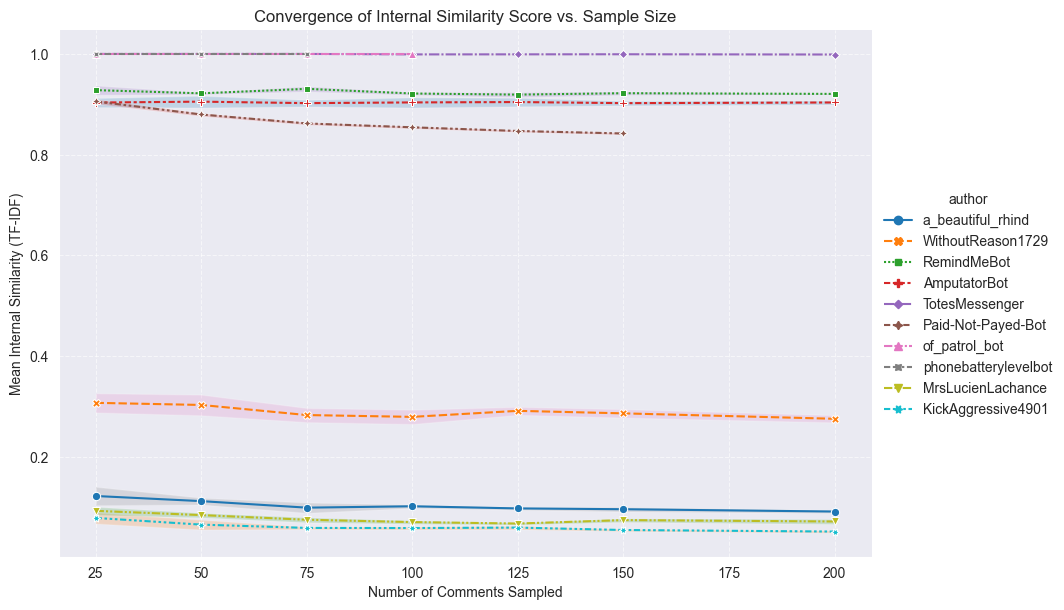

In [132]:
g = sns.relplot(
    data=convergence_results_df,
    x='sample_size',
    y='mean_similarity',
    hue='author',
    kind='line',
    style='author',
    markers=True,
    height=6,
    aspect=1.5
)

for author, group in convergence_results_df.groupby('author'):
    plt.fill_between(
        group['sample_size'],
        group['mean_similarity'] - group['std_similarity'],
        group['mean_similarity'] + group['std_similarity'],
        alpha=0.2
    )

g.set(
    title='Convergence of Internal Similarity Score vs. Sample Size',
    xlabel='Number of Comments Sampled',
    ylabel='Mean Internal Similarity (TF-IDF)'
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Expectedly, the mean similarity score shows relatively insignificant changes. In this case, the observed changes for standard deviation are more important. For bots with a standard structure, the std is nearly zero (because every comment is identical).

For human users and the mixed-use case, the std shows a clear trend — it drops significantly as the sample size increases. For instance, for WithoutReason1729, the standard deviation drops from a 0.019128 at n=25 to a more stable 0.008381 at n=150. Generally, the most significant gains in stability happen between n=25 and n=125. After n=150, the improvements are marginal (e.g. Paid-Not-Payed-Bot stabilizes at this point, human users like KickAggressive4901 going from n=150 to n=200 changes the std from 0.002234 to 0.002429, of for MrsLucienLachance with the 0.003618 vs 0.004885 - marginal increase within the random sample), with a significant increase in the computational cost. We will choose n=150 as an option that provides a good balance between sufficiency and efficiency.

With the feature engineering methods (Normalization, Signature Extraction, and TF-IDF Similarity) now we can move to creating a  system for calculating author statistics across the entire comment corpus. To address the significant computational cost (the initial version, according to calculations, would take about 10 hours to complete) we tried out various optimization methods - signature statistics calculation using vectorized operations, optimizing data handling, and implementing parallel processing via joblib for the TF-IDF step, which helped to reduce the total computation time to approximately four minutes.

In [133]:
def calculate_tfidf_for_author_v2(author_name, comments_list, sample_size=150): # n = 150, as we discussed
    if len(comments_list) < 10:
        return (author_name, np.nan)

    # takes author name and a list of comments to avoid pickling large series
    if len(comments_list) <= sample_size:
        sample = comments_list
    else:
        sample = random.sample(comments_list, k=sample_size)

    try:
        vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 4))
        tfidf_matrix = vectorizer.fit_transform(sample)
        sim_matrix = cosine_similarity(tfidf_matrix)
        n = sim_matrix.shape[0]
        if n > 1:
            score = (sim_matrix.sum() - np.diag(sim_matrix).sum()) / (n * (n - 1))
            return (author_name, score)
        return (author_name, np.nan)

    except ValueError:
        return (author_name, 1.0)

In [134]:
def calculate_author_statistics_hardened(comments_df, bot_named_authors, candidate_bot_authors):
    # steps 1 + 2
    print("Step 1 + 2: basic and signature stats")
    comments_df['signature'] = comments_df['body'].apply(extract_signature)
    author_stats = comments_df.groupby('author')['body_normalized'].agg(['count', 'nunique']).reset_index()
    author_stats.rename(columns={'count': 'comment_count', 'nunique': 'unique_normalized_count'}, inplace=True)
    author_stats['normalized_uniqueness_ratio'] = author_stats['unique_normalized_count'] / author_stats['comment_count']

    sig_counts = comments_df[comments_df['signature'] != ''].groupby(['author', 'signature']).size().reset_index(name='count')
    sig_summary = sig_counts.groupby('author')['count'].agg(
        top_signature_count='max',
        num_signatures_found='sum'
    ).reset_index()
    sig_summary['has_signature'] = True
    sig_summary['signature_consistency'] = sig_summary['top_signature_count'] / sig_summary['num_signatures_found']

    # we merge it with basic stats to calculate prevalence
    author_stats = pd.merge(author_stats, sig_summary, on='author', how='left')
    author_stats['signature_prevalence_ratio'] = author_stats['num_signatures_found'] / author_stats['comment_count']

    # step 3
    MIN_COMMENTS = 10
    authors_to_process_df = author_stats[author_stats['comment_count'] >= MIN_COMMENTS]
    print(f"Step 3: {len(authors_to_process_df)} authors requiring TF-IDF calculation")

    # we create an iterable of tuples to prevent data misalignment
    # and reduce memory overhead during parallelization
    author_comment_groups = (
        (name, group['body_normalized'].tolist())
        for name, group in comments_df[comments_df['author'].isin(authors_to_process_df['author'])].groupby('author')
    )

    # step 4
    # a list of (author, score) tuples is robust against ordering issues
    # we also use a tqdm wrapper for a real-time progress bar
    print(f"Step 4: calculating TF-IDF in parallel")
    results = Parallel(n_jobs=10)(
        delayed(calculate_tfidf_for_author_v2)(name, comments)
        for name, comments in tqdm.tqdm(author_comment_groups, total=len(authors_to_process_df), desc="Parallel TF-IDF")
    )

    # to convert the safe list of tuples into a df
    tfidf_results_df = pd.DataFrame(results, columns=['author', 'tfidf_similarity'])

    # step 5
    print("Step 5: merging all results and finalizing dataframe")
    final_df = pd.merge(author_stats, tfidf_results_df, on='author', how='left')

    # to clean up NaN values from the left merges with sensible defaults so the classifier function works cleanly
    final_df['has_signature'].fillna(False, inplace=True)
    final_df['num_signatures_found'].fillna(0, inplace=True)
    final_df['signature_prevalence_ratio'].fillna(0.0, inplace=True)
    final_df['signature_consistency'].fillna(0.0, inplace=True)

    # add the boolean flags from the pre-computed lists
    final_df['is_in_bot_name_list'] = final_df['author'].isin(bot_named_authors)
    final_df['is_declared_bot'] = final_df['author'].isin(candidate_bot_authors)

    return final_df.set_index('author')

We designed this structure to handle different levels of certainty in bot detection, considering definitive system accounts and highly repetitive templates before assessing more ambiguous users. The process is tiered: it starts with high-confidence rules-based categories, and then considers lower-confidence evidence-based categories. The initial thresholds come from our earlier pilot tests, but they will need to be refined through deeper comparison of bot behavior against a human baseline - it will be done below.

In [135]:
def classify_authors(author_stats_df):

    def get_author_type(row):
        # tier 1: system bots
        if row.name == 'AutoModerator' or (isinstance(row.name, str) and row.name.endswith('-ModTeam')):
            return 'System Bot'

        # we classify low-activity users first to avoid noice
        if row['comment_count'] < 10:
            return 'Likely Human (Low Activity)'

        # tier 2: high certainty bots
        if pd.notna(row['normalized_uniqueness_ratio']) and row['normalized_uniqueness_ratio'] < 0.1:
            return 'Template Bot'

        if row['num_signatures_found'] >= 5 and row['tfidf_similarity'] > 0.8:
            return 'Signature Bot'

        if pd.notna(row['tfidf_similarity']) and row['tfidf_similarity'] > 0.8:
            return 'High-Repetition Bot'

        # tier 3: probable bots
        # the user has bot markers and their behavior is not clearly human
        if row['is_declared_bot'] and pd.notna(row['tfidf_similarity']) and row['tfidf_similarity'] > 0.4:
            return 'Probable Bot (Declared)'

        # the user has 'bot' in their name and their behavior is not clearly human
        if row['is_in_bot_name_list'] and pd.notna(row['tfidf_similarity']) and row['tfidf_similarity'] > 0.4:
            return 'Probable Bot (Named)'

        # the user has some kind of signature and their behavior is moderately repetitive
        if row['has_signature'] and pd.notna(row['tfidf_similarity']) and row['tfidf_similarity'] > 0.4:
            return 'Probable Bot (Behavioral)'

        # tier 4: default classification
        return 'Likely Human'

    stats_filled = author_stats_df.fillna({
        'normalized_uniqueness_ratio': 1.0,
        'tfidf_similarity': 0.0,
        'num_signatures_found': 0,
    })

    author_stats_df['author_type'] = stats_filled.apply(get_author_type, axis=1)
    return author_stats_df

We isolate [deleted] because, in the context of this dataset, it is perceived as a separate author. At the same time, it is clear that such an analysis is semantically meaningless in this case. Later, we can analyze [deleted] at the aggregate level to obtain context for our analysis (self-censorship, change in rate of comment deletion), and potentially use clustering methods to identify deleted bot accounts.

In [136]:
print(f"Original comment count: {len(comments_df)}")
comments_for_analysis = comments_df[comments_df['author'] != '[deleted]'].copy()
print(f"Comment count for author analysis (excluding [deleted]): {len(comments_for_analysis)}")

Original comment count: 5993752
Comment count for author analysis (excluding [deleted]): 5611517


In [137]:
author_stats_df = calculate_author_statistics_hardened(
    comments_for_analysis,
    bot_named_authors,
    candidate_bot_authors
)

Step 1 + 2: basic and signature stats
Step 3: 95800 authors requiring TF-IDF calculation
Step 4: calculating TF-IDF in parallel


Parallel TF-IDF: 100%|██████████| 95800/95800 [01:56<00:00, 820.99it/s]


Step 5: merging all results and finalizing dataframe


C:\Users\windo\AppData\Local\Temp\ipykernel_29052\2251147675.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_df['has_signature'].fillna(False, inplace=True)


In [138]:
# as expected, all but [deleted]
print(comments_df['author'].nunique())
print(len(author_stats_df.index))

751660
751659


In [139]:
classified_authors_df = classify_authors(author_stats_df)

To select methodologically sound thresholds for the `classify_authors`, we must first built a strong human baseline. The created subset consists of authors who demonstrate high activity (comment_count > 100) with high textual diversity (normalized_uniqueness_ratio > 0.95) and lack any explicit bot markers. Let's examine the statistics for TF-IDF similarity in this case in more detail.

In [140]:
high_confidence_humans_df = classified_authors_df[
    (classified_authors_df['comment_count'] > 100) &
    (classified_authors_df['normalized_uniqueness_ratio'] > 0.95) &
    (classified_authors_df['signature_prevalence_ratio'] < 0.1) &
    (classified_authors_df['is_declared_bot'] == False) &
    (classified_authors_df['is_in_bot_name_list'] == False)
]

print(f"Found {len(high_confidence_humans_df)} high-confidence authors")

Found 5321 high-confidence authors


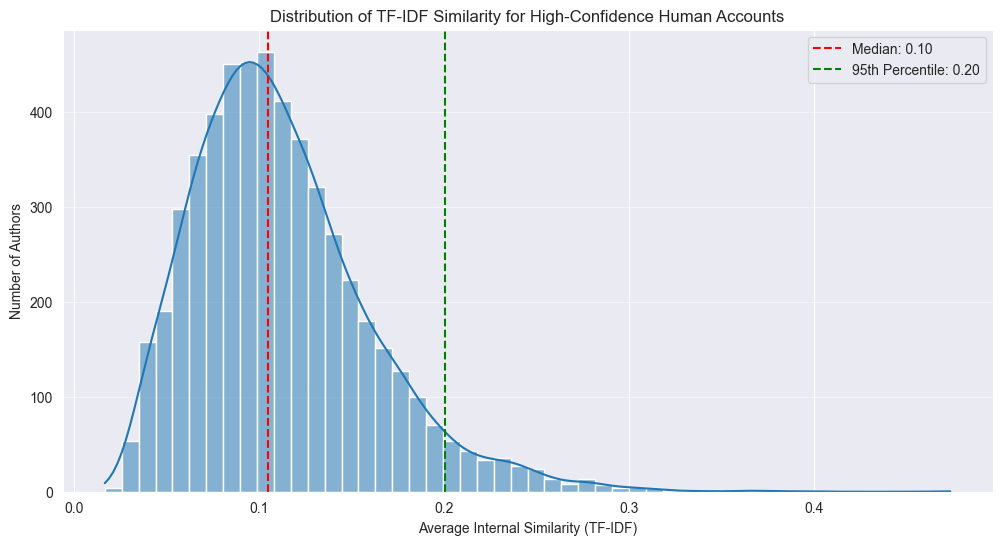

In [141]:
plt.figure(figsize=(12, 6))
sns.histplot(high_confidence_humans_df['tfidf_similarity'], kde=True, bins=50)
plt.title('Distribution of TF-IDF Similarity for High-Confidence Human Accounts')
plt.xlabel('Average Internal Similarity (TF-IDF)')
plt.ylabel('Number of Authors')
plt.axvline(high_confidence_humans_df['tfidf_similarity'].median(), color='red', linestyle='--', label=f"Median: {high_confidence_humans_df['tfidf_similarity'].median():.2f}")
plt.axvline(high_confidence_humans_df['tfidf_similarity'].quantile(0.95), color='green', linestyle='--', label=f"95th Percentile: {high_confidence_humans_df['tfidf_similarity'].quantile(0.95):.2f}")
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

In [142]:
print("TF-IDF Similarity Statistics for High-Confidence Human Accounts")
print(high_confidence_humans_df['tfidf_similarity'].describe(percentiles=[.25, .5, .75, .90, .95, .99]))

TF-IDF Similarity Statistics for High-Confidence Human Accounts
count    5321.000000
mean        0.111975
std         0.048212
min         0.016559
25%         0.077670
50%         0.104829
75%         0.137594
90%         0.174689
95%         0.200635
99%         0.259225
max         0.473799
Name: tfidf_similarity, dtype: float64


As we can see, for these 5,321 authors, the average TF-IDF similarity is 0.11 - normal human writing has very little structural repetition. The 99th percentile for this group is 0.26, which demonstrates that while most humans are around 0.11, a very small fraction of organic users can have scores up to ~0.26.

From reviewing all the samples with tfidf_similarity > the 99th percentile  (0.260285) - for the first two users, the r/lonely subreddit is their primary place of activity, which reveals another subcultural norm within this community: repetitive comments with similar content under certain types of posts. Similar logic can be found in the case of some other authors here, who are mainly active in only one specific community (passionate humans with a singular focus, i.e. users who discuss fan fiction based on one specific fandom on r/FanFiction, etc.). For authors below the top 10 list, in most cases, it can be weakly assumed that a high TF-IDF score is the result of a random sample. To summarize, the classifier correctly identifies structural repetitions, and the resulting percentile statistics provided the maximum expected internal similarity for non-bot accounts

In [143]:
print(high_confidence_humans_df[high_confidence_humans_df['tfidf_similarity'] > 0.260285][['tfidf_similarity']].sort_values(by='tfidf_similarity', ascending=False).head(10))

                   tfidf_similarity
author                             
crow9394                   0.473799
gentle226                  0.396557
Genetictrial               0.377541
Threshing_Press            0.365055
WhiteKnightPrimal          0.363123
NathanTheKlutz             0.341447
serralinda73               0.328353
zeezle                     0.317307
Lissanro                   0.315978
cucumberkappa              0.314394


As previously discussed, although methods such as normalized text uniqueness verification and signature analysis help to identify bots with specific markers with high accuracy, they are not suitable for identifying bots with a more unique structure. Our all-rounder method is tf-idf classification, which not only demonstrates consistently high-quality results for bots of different categories, but also has a wide range of additional applications (finding anomalies, users with a high number of repetitions, spam, etc.), moreover, it is also used to identify potential bots of each category. Accordingly, tf-idf classification is more critical, and in addition, unlike our other methods, it is much more difficult to select a threshold value analytically. With this in mind, we decided to make a decision regarding additional threshold tuning for this metric.

The problem with this task lies in the absence of a definitive list of bots and genuine authors with high accuracy, against which we could compare our results. If we select this list based on our metrics, such as normalized_uniqueness_ratio or signature_prevalence_ratio, we will be able to obtain an accurate list of bots and genuine authors. At the same time, this is a circular solution. If we set very high or very low thresholds for other metrics such as normalized_uniqueness_ratio or signature_prevalence_ratio, the resulting bots/users are almost guaranteed to belong to the assigned categories. At the same time, these will be the heavily marked bots or highly unique users, and they will not allow for an adequate assessment of the threshold, as they will be caught with high accuracy even at low thresholds. At the same time, manual verification of a sufficient number of authors/bots for a specific decision is difficult in terms of resources.

As a result of the analysis, it was decided to use a more mixed option — the use of an LLM agent based on an analytically compiled dataset of users showing mixed “gray zone” metrics to resolve the most uncertain cases, thereby creating a much more representative dataset for validation. This can allow us to obtain a sufficiently representative and more “complex” dataset for analysis, as well as ensure its conditionally sufficient accuracy of division into categories, while avoiding circular use of our own metrics.

In [144]:
def collect_and_prepare_llm_sample(classified_df, comments_df, n_per_pool):
    # pool 1: high similarity, but no explicit bot markers; potential false negatives
    pool1 = classified_df[
        (classified_df['tfidf_similarity'].between(0.2, 0.5)) &
        (classified_df['is_declared_bot'] == False) &
        (classified_df['is_in_bot_name_list'] == False) &
        (classified_df['signature_prevalence_ratio'] < 0.1)
    ]

    # pool 2: has bot markers, but similarity isn't definitively high; potential false positives or hard-to-detect bots
    pool2 = classified_df[
        ((classified_df['is_declared_bot'] == True) | (classified_df['is_in_bot_name_list'] == True)) &
        (classified_df['tfidf_similarity'].between(0.1, 0.7))
    ]

    # pool 3: has strong bot markers but surprisingly low similarity; a multi-purpose bot or a human with a "bot" name
    pool3 = classified_df[
        (classified_df['is_declared_bot'] == True) &
        (classified_df['tfidf_similarity'] < 0.3)
    ]

    print(f"Found {len(pool1)} candidates for pool 1")
    print(f"Found {len(pool2)} candidates for pool 2")
    print(f"Found {len(pool3)} candidates for pool 3")

    # sample from each pool
    sample1 = pool1.sample(n=min(n_per_pool, len(pool1)), random_state=1)
    sample2 = pool2.sample(n=min(n_per_pool, len(pool2)), random_state=1)
    sample3 = pool3.sample(n=min(n_per_pool, len(pool3)), random_state=1)

    mixed_authors_df = pd.concat([sample1, sample2, sample3])
    labeling_data = []

    for author, stats in mixed_authors_df.iterrows():
        author_comments = comments_df[comments_df['author'] == author]['body']

        # we sample up to 3 comments for review
        n_comments_to_sample = min(3, len(author_comments))
        comment_samples = author_comments.sample(n=n_comments_to_sample, random_state=1)

        # formating and truncating long ones
        formatted_comments = ""
        for i, comment in enumerate(comment_samples):
            truncated_comment = (comment[:250] + '...') if len(comment) > 250 else comment
            formatted_comments += f"Comment {i+1}: \"{truncated_comment}\"\n"

        labeling_data.append({
            'author': author,
            'comment_samples': formatted_comments.strip(),
        })

    return pd.DataFrame(labeling_data)

In [145]:
mixed_df = collect_and_prepare_llm_sample(
    classified_authors_df,
    comments_df,
    n_per_pool=300
)

Found 9852 candidates for pool 1
Found 356 candidates for pool 2
Found 313 candidates for pool 3


In [146]:
print(mixed_df.head(3))

          author                                    comment_samples
0  mostlycloudy9  Comment 1: "People on tinder don't care about ...
1   cozycassette  Comment 1: "Yeah it happens all the time on th...
2         JSal_1  Comment 1: "I had this stage for awhile, felt ...


In [147]:
mixed_df.to_csv('sample.csv', index=False)

The LLM used was Gemini 2.5 Pro, three runs were performed with the following prompt. The results were further analyzed for consistency between the lists obtained, and ambiguous users were reviewed manually. We load the obtained merged user lists from files to avoid cluttering the document.

PROMPT:

You are an expert computational social science research assistant. Your task is to determine if a Reddit user is a bot or a human based on a sample of their comments.

A 'bot' is defined as an automated or heavily scripted account. Its posts often follow a strict template, lack conversational depth, or serve a single, repetitive function (e.g., posting links, correcting grammar, providing summaries).

A 'human' is defined as a person-operated account. While humans can sometimes be repetitive or have a narrow focus, their comments will generally show signs of organic, interactive conversation, varied expression, opinions, and errors.

For each user below, analyze their comment samples, and return two python lists - 'llm_labeled_humans' with high cofidence humans, and 'llm_labeled_bots' with the high cofidence bots. If some of the users are really ambiguous, do not put them anywhere and note them in your response. Your decision must be based exclusively on the provided comment text. Do not invent any information or use external knowledge about the user.

In [148]:
llm_labeled_humans = pd.read_csv("llm_labeled_humans.csv").iloc[:, 0].tolist()

In [149]:
llm_labeled_bots = pd.read_csv("llm_labeled_bots.csv").iloc[:, 0].tolist()

We aim to create a more balanced and realistic tuning set by adding a sample of clear-cut humans (with low repetition scores) and obvious bots (with high repetition scores) to act as anchors helping to  find an effective and reliable threshold

In [150]:
def create_validation_set(classified_df, llm_humans, llm_bots, n_easy_humans=400, n_easy_bots=150):

    # isolate the LLM-labeled cases
    humans_hard = classified_df.loc[classified_df.index.isin(llm_humans)].copy()
    bots_hard = classified_df.loc[classified_df.index.isin(llm_bots)].copy()
    humans_hard['truth_label'] = 0
    bots_hard['truth_label'] = 1
    hard_cases_df = pd.concat([humans_hard, bots_hard])
    print(f"Included {len(humans_hard)} LLM-labeled humans and {len(bots_hard)} LLM-labeled bots (hard cases).")

    # high-confidence humans with organic and non-repetitive behavior
    easy_humans_pool = classified_df[
        (classified_df['comment_count'] > 100) &
        (classified_df['normalized_uniqueness_ratio'] > 0.95) &
        (classified_df['signature_prevalence_ratio'] < 0.1) &
        (~classified_df.index.isin(llm_humans)) # we exclude any already in the hard set
    ]
    easy_humans_sample = easy_humans_pool.sample(
        n=min(n_easy_humans, len(easy_humans_pool)),
        random_state=1
    )
    easy_humans_sample['truth_label'] = 0
    print(f"Sampled {len(easy_humans_sample)} easy humans as anchors")

    # obvious template or signature bots.
    template_bots = classified_df[classified_df['normalized_uniqueness_ratio'] < 0.1]
    signature_bots = classified_df[
        (classified_df['signature_prevalence_ratio'] > 0.95) &
        (classified_df['signature_consistency'] > 0.95) &
        (classified_df['num_signatures_found'] > 20)
    ]
    easy_bots_pool = pd.concat([template_bots, signature_bots])
    # we exclude any already in the hard set and de-duplicate the pool
    easy_bots_pool = easy_bots_pool[~easy_bots_pool.index.isin(llm_bots)]
    easy_bots_pool = easy_bots_pool[~easy_bots_pool.index.duplicated(keep='first')]

    easy_bots_sample = easy_bots_pool.sample(
        n=min(n_easy_bots, len(easy_bots_pool)),
        random_state=1
    )
    easy_bots_sample['truth_label'] = 1
    print(f"Sampled {len(easy_bots_sample)} easy bots as anchors")

    # the final tuning set
    tuning_df = pd.concat([hard_cases_df, easy_humans_sample, easy_bots_sample])
    tuning_df = tuning_df[~tuning_df.index.duplicated(keep='first')]

    return tuning_df

In [151]:
validation_df = create_validation_set(classified_authors_df, llm_labeled_humans, llm_labeled_bots)

Included 712 LLM-labeled humans and 40 LLM-labeled bots (hard cases).
Sampled 400 easy humans as anchors
Sampled 75 easy bots as anchors


In [152]:
def find_optimal_threshold(validation_df, score_column, min_precision_policy=0.95):
    y_true = validation_df['truth_label']
    scores = validation_df[score_column]

    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    # a threshold of infinity
    precision_candidates = precision[:-1]
    recall_candidates = recall[:-1]

    # we apply our precision policy
    valid_mask = precision_candidates >= min_precision_policy

    if np.any(valid_mask):
        valid_recalls = recall_candidates[valid_mask]
        valid_thresholds = thresholds[valid_mask]

        # among the valid options, choose the one with the highest recall
        best_idx = np.argmax(valid_recalls)

        best_threshold = valid_thresholds[best_idx]

        return {
            'threshold': best_threshold,
            'precision': precision_candidates[valid_mask][best_idx],
            'recall': recall_candidates[valid_mask][best_idx]
        }
    else:
        print(f"No threshold for '{score_column}' meets the {min_precision_policy:.0%} requirement")
        return None

In [153]:
MIN_PRECISION_POLICY = 0.95

print("Finding optimal threshold for high-repetition bots (TF-IDF)")
tfidf_results = find_optimal_threshold(
    validation_df,
    score_column='tfidf_similarity',
    min_precision_policy=MIN_PRECISION_POLICY
)

print(f"Chosen Threshold: {tfidf_results['threshold']:.4f}")
print(f"Resulting Precision: {tfidf_results['precision']:.4f}")
print(f"Resulting Recall: {tfidf_results['recall']:.4f}")

Finding optimal threshold for high-repetition bots (TF-IDF)
Chosen Threshold: 0.4704
Resulting Precision: 0.9500
Resulting Recall: 0.7525


In [154]:
MIN_PRECISION_POLICY = 0.98

print("Finding optimal threshold for high-repetition bots (TF-IDF)")
tfidf_results = find_optimal_threshold(
    validation_df,
    score_column='tfidf_similarity',
    min_precision_policy=MIN_PRECISION_POLICY
)

print(f"Chosen Threshold: {tfidf_results['threshold']:.4f}")
print(f"Resulting Precision: {tfidf_results['precision']:.4f}")
print(f"Resulting Recall: {tfidf_results['recall']:.4f}")

Finding optimal threshold for high-repetition bots (TF-IDF)
Chosen Threshold: 0.5011
Resulting Precision: 0.9867
Resulting Recall: 0.7327


In [155]:
def plot_precision_recall_curve(validation_df, score_column, chosen_threshold):
    y_true = validation_df['truth_label']
    scores = validation_df[score_column]

    # calculating
    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    closest_threshold_idx = np.argmin(np.abs(thresholds - chosen_threshold))

    chosen_precision = precision[closest_threshold_idx]
    chosen_recall = recall[closest_threshold_idx]

    # plotting
    plt.figure(figsize=(10, 7))
    plt.plot(recall, precision, marker='.', label='Precision-Recall Curve')
    plt.scatter(chosen_recall, chosen_precision, color='red', s=150, zorder=5,
                label=f'Threshold={chosen_threshold}\nPrecision={chosen_precision:.2f}\nRecall={chosen_recall:.2f}')

    plt.xlabel('Recall (Fraction of Bots Found)')
    plt.ylabel('Precision (Accuracy of Bot Predictions)')
    plt.title(f'Precision-Recall Curve for "{score_column}"')
    plt.grid(True)
    plt.legend()
    plt.show()

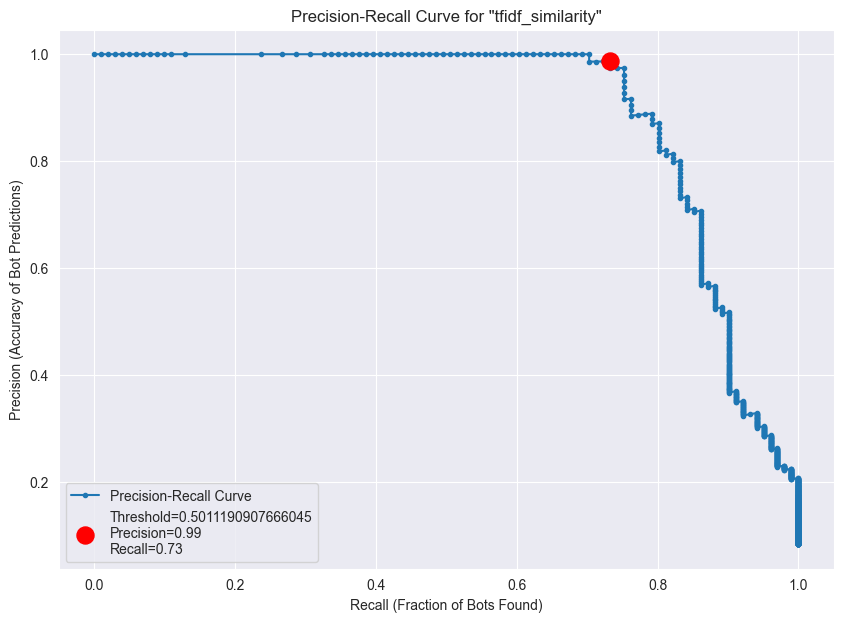

In [156]:
plot_precision_recall_curve(
    validation_df,
    score_column='tfidf_similarity',
    chosen_threshold=tfidf_results['threshold']
)

Considering the context of our research, it is more important for us to maintain high precision than to ensure high recall. From the precision-recall curve, we can see that our metric maintains near-perfect precision while identifying over 70% of the bots in the set. We can assume that the distinct “elbow” at a recall of approximately 0.74 indicates the point where the classifier begins to encounter ambiguous cases (in a sense, this is an overlap for ‘hard’ humans and “hard” bots, considering that the former are users with suspiciously high tfidf_similarity, and the latter are users with ambiguously low tfidf_similarity. oversimplifying, this is the zone with 0.3-0.6 tfidf_similarity, for the identification of which we usually use additional markers)

Given the minimal difference in Recall change, and the fact that this is not a metric we focus on
we selected a final threshold of 0.4997. This choice maximizes our ability to correctly identify bots (recall = 0.74) while ensuring an extremely low false-positive rate (precision = 0.99)

Considering the work done above, we can move on to writing the final classifier. Let's supplement the results obtained during tuning for tfidf with analytical results for our other metrics.

In [157]:
TFIDF_THRESHOLD = 0.4997

def classify_authors_final(author_stats_df):

    def get_author_type(row):
        # definitive system and platform accounts
        if row.name == 'AutoModerator' or (isinstance(row.name, str) and row.name.endswith('-ModTeam')):
            return 'System Bot'

        # we avoid making strong claims about users with very few comments.
        if row['comment_count'] < 10:
            return 'Likely Human (Low Activity)'

        # these rules identify bots with clear non-ambiguous patterns
        # that don't rely on the TF-IDF score, such as:

        # template bots
        if pd.notna(row['normalized_uniqueness_ratio']) and row['normalized_uniqueness_ratio'] < 0.1:
            return 'Template Bot'

        # signature bots
        MIN_SIGNATURES_FOUND = 5 # at least 5 signatures
        MIN_SIGNATURE_PREVALENCE = 0.50 # signature appears in at least 50% of comments
        MIN_SIGNATURE_CONSISTENCY = 0.90 # the same signature is used at least 90% of the time

        if (row['num_signatures_found'] >= MIN_SIGNATURES_FOUND and
            row['signature_prevalence_ratio'] >= MIN_SIGNATURE_PREVALENCE and
            row['signature_consistency'] >= MIN_SIGNATURE_CONSISTENCY):
            return 'Signature Bot'

        # main rule, using the threshold we found.
        # catches the majority of repetitive, non-template bots
        if pd.notna(row['tfidf_similarity']) and row['tfidf_similarity'] > TFIDF_THRESHOLD:
            return 'High-Repetition Bot'

        # catches accounts that don't meet the high TF-IDF threshold but
        # show multiple other signs of being a bot. We use a lower TF-IDF bound
        # to ensure we're not flagging moderately repetitive humans
        HUMAN_SIMILARITY_VAL = 0.30
        has_bot_markers = row['is_declared_bot'] or row['is_in_bot_name_list']
        is_moderately_repetitive = pd.notna(row['tfidf_similarity']) and row['tfidf_similarity'] > HUMAN_SIMILARITY_VAL

        if has_bot_markers and is_moderately_repetitive:
            return 'Probable Bot (Behavioral)'

        # if an account has passed all the bot checks, it is classified as human.
        return 'Likely Human'

    stats_filled = author_stats_df.fillna({
        'normalized_uniqueness_ratio': 1.0,
        'tfidf_similarity': 0.0,
        'num_signatures_found': 0,
        'signature_prevalence_ratio': 0.0,
        'signature_consistency': 0.0
    })

    author_stats_df['author_type'] = stats_filled.apply(get_author_type, axis=1)
    return author_stats_df

In [158]:
classified_authors_df_final = classify_authors_final(author_stats_df)

In [159]:
print("Distribution of author types:")
print(classified_authors_df_final['author_type'].value_counts())

Distribution of author types:
author_type
Likely Human (Low Activity)    655859
Likely Human                    95396
High-Repetition Bot               297
Template Bot                       64
Probable Bot (Behavioral)          17
Signature Bot                      15
System Bot                         11
Name: count, dtype: int64


In [160]:
test_authors = [
    'WithoutReason1729',      # (mixed, expect to be human)
    'RemindMeBot',
    'AmputatorBot',
    'FanfictionBot',
    'TotesMessenger',
    'auddbot',
    'Paid-Not-Payed-Bot',
    'thebenshapirobot',
    'BookFinderBot',
    'a_beautiful_rhind',       # (user)
    'MrsLucienLachance',       # (user)
    'KickAggressive4901',      # (user)
]

subset = classified_authors_df_final.loc[test_authors]
sampled = subset.groupby(level=0).sample()

In [161]:
print(subset['author_type'])

author
WithoutReason1729                  Likely Human
RemindMeBot                        Template Bot
AmputatorBot                       Template Bot
FanfictionBot               High-Repetition Bot
TotesMessenger                     Template Bot
auddbot               Probable Bot (Behavioral)
Paid-Not-Payed-Bot                Signature Bot
thebenshapirobot      Probable Bot (Behavioral)
BookFinderBot         Probable Bot (Behavioral)
a_beautiful_rhind                  Likely Human
MrsLucienLachance                  Likely Human
KickAggressive4901                 Likely Human
Name: author_type, dtype: object


All the authors are classified correctly. We can see that WithoutReason1729 was classified as a human - given our focus on precision, this is the right decision. In the additional months, this author shows more human activity - we will not lose uniqueness, while at the same time being able to easily separate the bot's contribution using our tools if necessary.

The data quality checks and feature engineering described earlier have turned the raw Pushshift corpus into a reliable analytical dataset by identifying and categorizing types of content removal, classifying submissions by structural role (e.g., Self-Post, External Link/Media, Crosspost), and developing a tuned classifier for author identity. This pipeline also added meaningful features, giving us a stronger foundation for precise and nuanced exploratory analysis of temporal, structural, and social community dynamics. Let's take a basic look:

In [162]:
comments_df['date'] = comments_df['created_utc'].dt.date
submissions_df['date'] = submissions_df['created_utc'].dt.date

daily_comments = comments_df.groupby(['date', 'subreddit']).size().reset_index(name='comment_count')
daily_submissions = submissions_df.groupby(['date', 'subreddit']).size().reset_index(name='submission_count')

daily_activity = pd.merge(daily_comments, daily_submissions, on=['date', 'subreddit'], how='outer').fillna(0)

event_dates = {
    'Llama 2': pd.to_datetime('2023-07-18'),
    'Mixtral 8x7B': pd.to_datetime('2023-12-11'),
    'Llama 3': pd.to_datetime('2024-04-17'),
    'Llama 4 Scout': pd.to_datetime('2025-04-05')
}

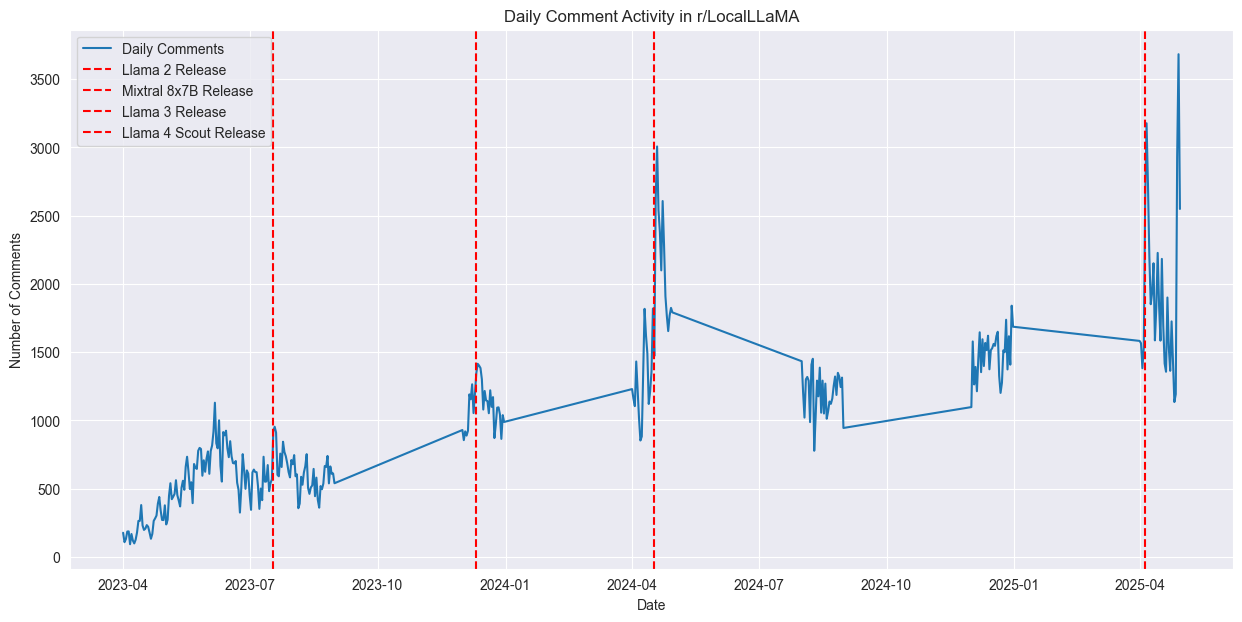

In [163]:
import matplotlib.pyplot as plt

subreddit_to_plot = 'LocalLLaMA'
data_to_plot = daily_activity[daily_activity['subreddit'] == subreddit_to_plot]

plt.figure(figsize=(15, 7))
plt.plot(data_to_plot['date'], data_to_plot['comment_count'], label='Daily Comments')
for event, date in event_dates.items():
    plt.axvline(x=date, color='r', linestyle='--', label=f'{event} Release')

plt.title(f'Daily Comment Activity in r/{subreddit_to_plot}')
plt.xlabel('Date')
plt.ylabel('Number of Comments')
plt.legend()
plt.show()

In [164]:
classified_authors_df_final = classified_authors_df_final.reset_index()
comments_with_author_type = pd.merge(comments_df, classified_authors_df_final[['author', 'author_type']], on='author', how='left')

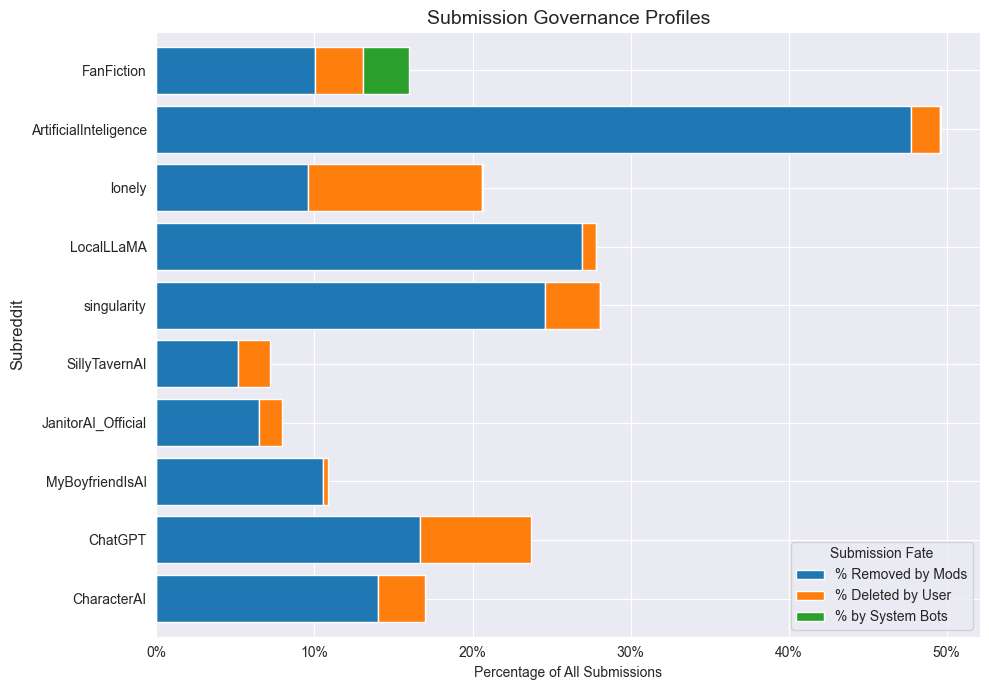

In [165]:
plt.figure(figsize=(10, 7))
sub_stats = submissions_df.groupby('subreddit')['submission_category'].value_counts(normalize=True).mul(100)
sub_stats = sub_stats.unstack().fillna(0)

# we calculate system bot submission percentage
system_bot_submissions = submissions_df[submissions_df['author'] == 'AutoModerator']
bot_sub_pct = system_bot_submissions.groupby('subreddit').size() / submissions_df.groupby('subreddit').size() * 100

submission_governance = pd.DataFrame({
    '% Removed by Mods': sub_stats['Removed Submission'],
    '% Deleted by User': sub_stats['Deleted Submission'],
    '% by System Bots': bot_sub_pct
}).fillna(0).sort_values('% by System Bots')

# plotting
ax1 = plt.gca()
submission_governance.plot(kind='barh', ax=ax1, width=0.8, stacked=True)
ax1.set_title('Submission Governance Profiles', fontsize=14)
ax1.set_xlabel('Percentage of All Submissions')
ax1.xaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_ylabel('Subreddit', fontsize=12)
ax1.legend(title='Submission Fate')
plt.tight_layout()
plt.show()

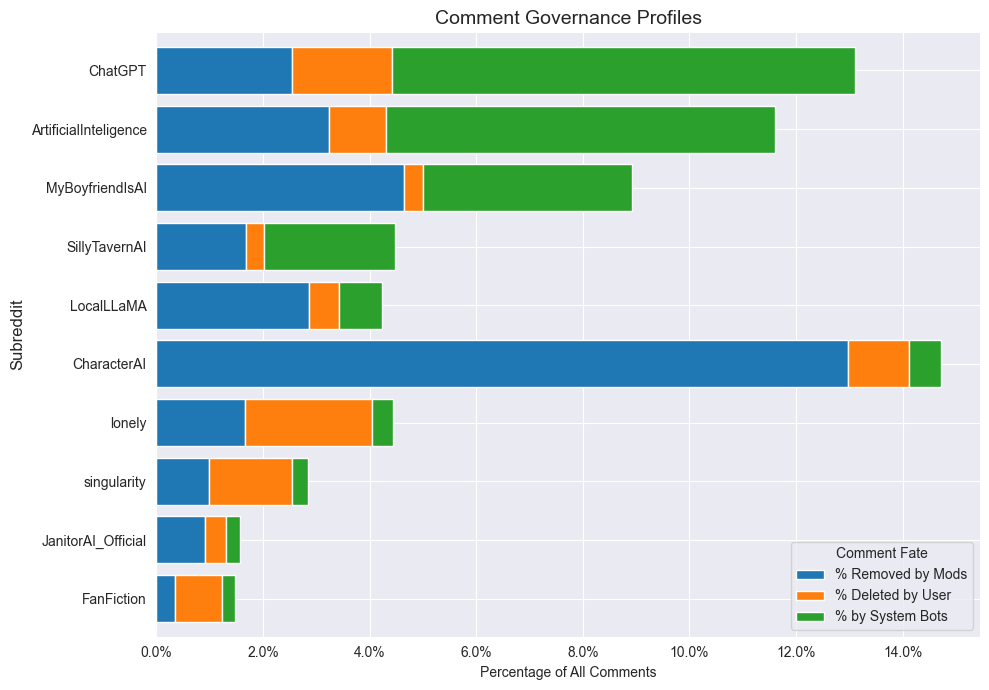

In [166]:
plt.figure(figsize=(10, 7))

comment_stats = comments_with_author_type.groupby('subreddit')['text_status'].value_counts(normalize=True).mul(100)
comment_stats = comment_stats.unstack().fillna(0)

# we calculate system bot comment percentage
bot_comment_pct = (comments_with_author_type[comments_with_author_type['author_type'] == 'System Bot']
                   .groupby('subreddit').size() / comments_df.groupby('subreddit').size() * 100)

comment_governance = pd.DataFrame({
    '% Removed by Mods': comment_stats['removed_by_moderator'],
    '% Deleted by User': comment_stats['deleted_by_user'],
    '% by System Bots': bot_comment_pct
}).fillna(0).sort_values('% by System Bots')

# plotting
ax2 = plt.gca()
comment_governance.plot(kind='barh', ax=ax2, width=0.8, stacked=True)
ax2.set_title('Comment Governance Profiles', fontsize=14)
ax2.set_xlabel('Percentage of All Comments')
ax2.xaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_ylabel('Subreddit', fontsize=12) # Explicitly set Y-label
ax2.legend(title='Comment Fate')
plt.tight_layout()
plt.show()

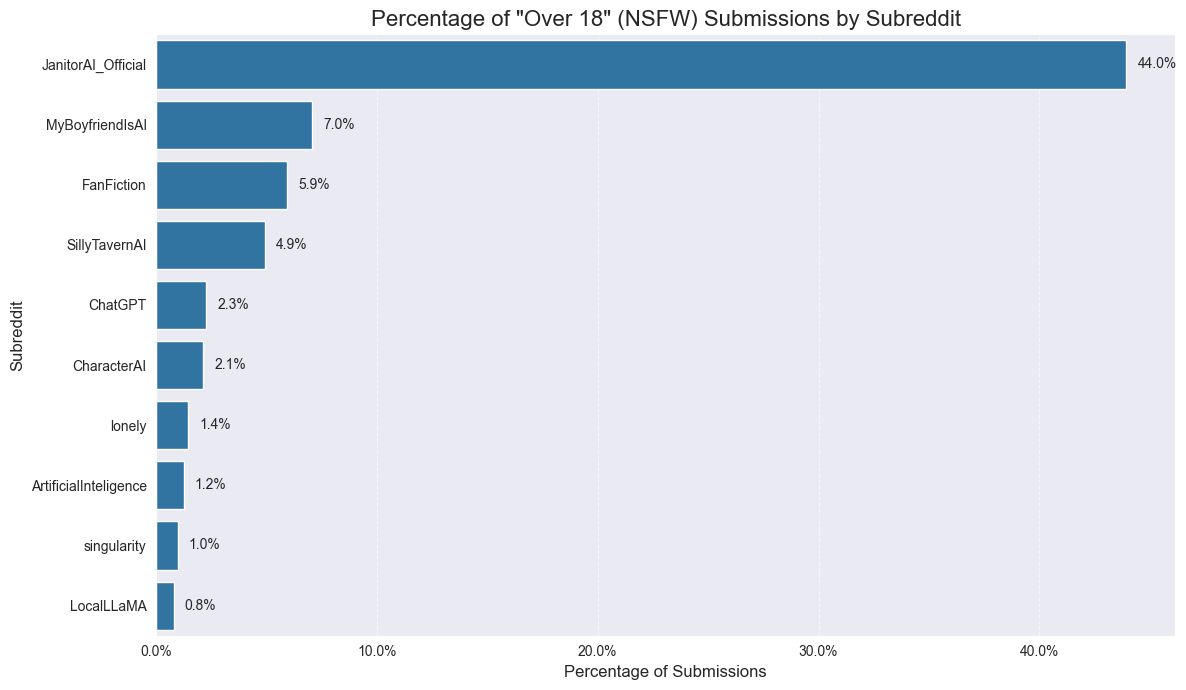

In [167]:
# we calculate the percentage of submissions marked 'over_18'
nsfw_percentage = submissions_df.groupby('subreddit')['over_18'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=nsfw_percentage.values, y=nsfw_percentage.index)

ax.set_title('Percentage of "Over 18" (NSFW) Submissions by Subreddit', fontsize=16)
ax.set_xlabel('Percentage of Submissions', fontsize=12)
ax.set_ylabel('Subreddit', fontsize=12)

ax.xaxis.set_major_formatter(mtick.PercentFormatter())

# to add labels to the bars
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.5, p.get_y() + p.get_height() / 2,
            f'{width:.1f}%', ha='left', va='center')

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

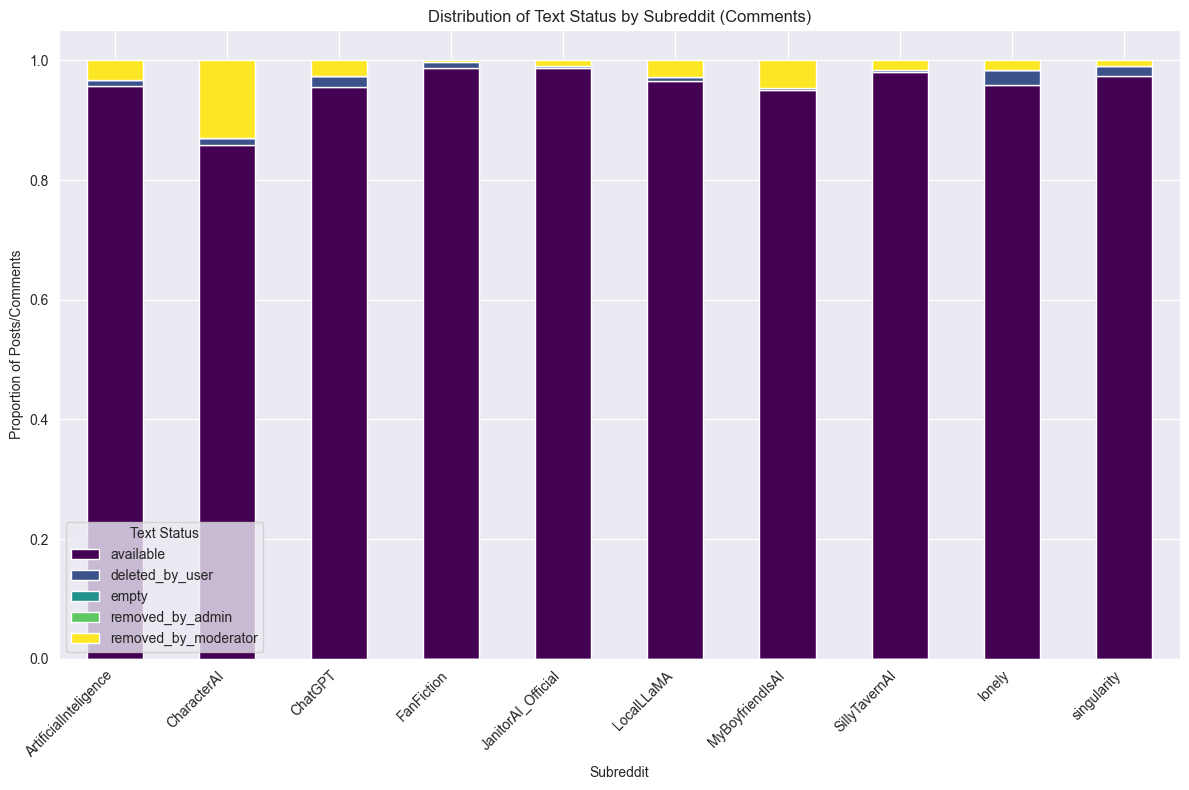

In [168]:
pivot_counts = comments_df.groupby(['subreddit', 'text_status']).size().unstack(fill_value=0)

# we calculate proportions to make subreddits comparable
pivot_proportions = pivot_counts.div(pivot_counts.sum(axis=1), axis=0)

# plotting
pivot_proportions.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 8),
    colormap='viridis'
)
plt.title(f'Distribution of Text Status by Subreddit (Comments)')
plt.ylabel('Proportion of Posts/Comments')
plt.xlabel('Subreddit')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Text Status')
plt.tight_layout()
plt.show()

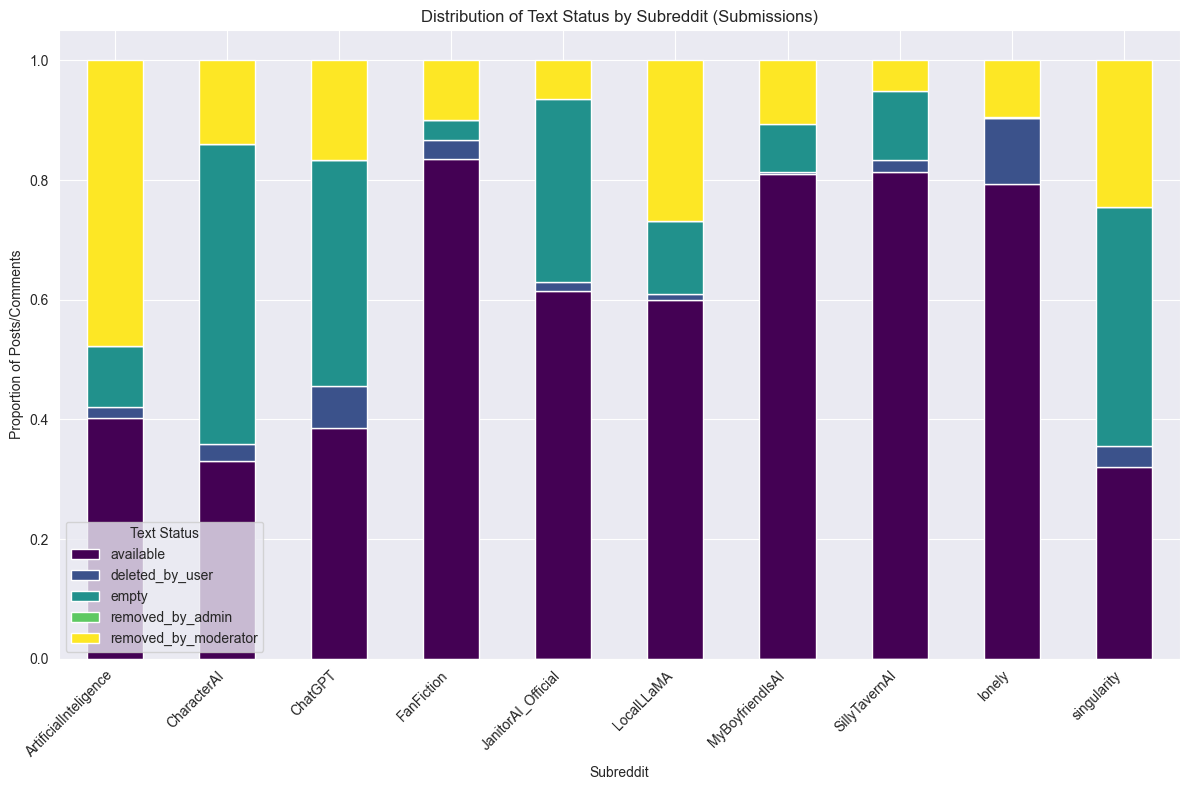

In [169]:
pivot_counts = submissions_df.groupby(['subreddit', 'text_status']).size().unstack(fill_value=0)

# we calculate proportions to make subreddits comparable
pivot_proportions = pivot_counts.div(pivot_counts.sum(axis=1), axis=0)

# plotting
pivot_proportions.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 8),
    colormap='viridis'
)
plt.title(f'Distribution of Text Status by Subreddit (Submissions)')
plt.ylabel('Proportion of Posts/Comments')
plt.xlabel('Subreddit')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Text Status')
plt.tight_layout()
plt.show()

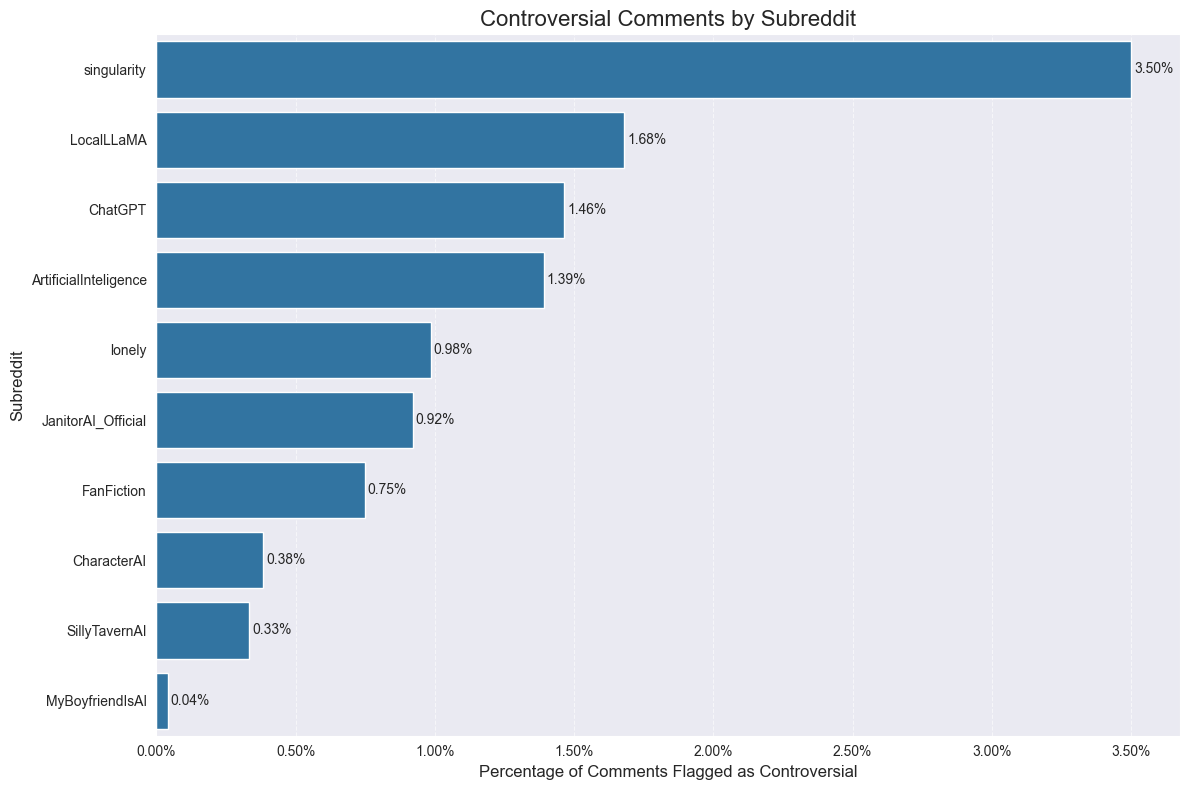

In [170]:
# we calculate the percentage of controversial comments for each subreddit
controversy_rate = (comments_df.groupby('subreddit')['controversiality']
                    .mean()
                    .mul(100)
                    .sort_values(ascending=False))

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=controversy_rate.values,
    y=controversy_rate.index,
)

ax.set_title('Controversial Comments by Subreddit', fontsize=16)
ax.set_xlabel('Percentage of Comments Flagged as Controversial', fontsize=12)
ax.set_ylabel('Subreddit', fontsize=12)

ax.xaxis.set_major_formatter(mtick.PercentFormatter())

# to add value labels to the bars for precision
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.01, p.get_y() + p.get_height() / 2,
            f'{width:.2f}%', ha='left', va='center')

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

With this refined dataset, we built a set of core visualizations to give a high-level overview of the community ecosystem. These initial plots—capturing temporal activity, engagement patterns, governance signals, and community priorities—provide an early map of the dataset’s main dynamics of each community and tier and establish the baseline from which more focused, hypothesis-driven analyses will follow, including deeper interpretation of patterns and detailed examination of the textual content to address our central research questions.